# Final Evaluation: Warmup Learning Curves

Evaluate trained DQN agents against a heuristic baseline on parameterized
`ScalableEvalScenario` scenarios with **physics-guaranteed feasibility**.

**Pipeline:**
1. Load pre-trained agents from tutorial checkpoints
2. (Optional) Fine-tune on urgency scenarios (S32/S33)
3. Run warmup training on each scenario, recording **per-epoch learning curves**
4. Run heuristic baseline once per scenario
5. Plot agent adaptation curves vs. heuristic baseline
6. Focus on **sub-task completion percentages** and trends

In [1]:
# ================================================================
# Cell 1: Imports & Configuration
# ================================================================
import os, sys, random, time, warnings
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

# Add project root to path (notebook is in notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})
warnings.filterwarnings('ignore', category=FutureWarning)

# Project imports
from simulation.training.curriculum_trainer import (
    create_env_factory, build_agent_config,
)
from simulation.rl.agent_registry import create_agent
from simulation.training.tutorial_runner import TutorialRunner
from simulation.training.scenarios import SCENARIO_BY_ID
from simulation.training.eval import (
    ScalableEvalScenario, EvalParams, HeuristicAgent,
)

# ── User configuration ────────────────────────────────────────
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Agents to evaluate: list of (dqn_variant, cnn_backbone) tuples.
AGENTS_TO_EVAL = [
    ("baseline",      "baseline"),
    ("baseline",      "narrow_deep"),
    ("gru",      "narrow_deep"),
    ("noisynet",      "narrow_deep"),
    ("munchausen",    "baseline"),
    ("spectral_norm", "deeper"),
    # ("noisynet",      "region_aware"),
]

def agent_label(variant: str, backbone: str) -> str:
    return f"{variant}_{backbone}"

# Paths
CKPT_DIR = PROJECT_ROOT / 'runs' / 'tutorial_checkpoints'
OUTPUT_DIR = PROJECT_ROOT / 'runs' / 'final_eval'
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Warmup settings (per-combo adaptation — this IS the evaluation)
WARMUP_EPOCHS = 30         # Training episodes per scenario combo
WARMUP_EPSILON = 0.10      # Exploration during warmup
WARMUP_GRAD_STEPS = 4      # Gradient steps per warmup episode

# Training from scratch (fallback if no checkpoint)
TRAIN_EPOCHS = 800
MASTERY_THRESHOLD = 0.9

# Fine-tuning (optional, Cell 4/6)
SKIP_FINETUNE = True       # Set False to fine-tune on urgency scenarios first
FINETUNE_EPOCHS = 50
FINETUNE_EPSILON = 0.05
FINETUNE_SCENARIOS = [32, 33]

# Eval grid: imports up to 100, exports up to 100 → total up to 200
LOAD_SIZES = [40, 80, 120, 200, 300, 400]
YARD_FILLS = [0.0, 0.25, 0.50]
BASE_SEED = 7000

print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')
print(f'Agents ({len(AGENTS_TO_EVAL)} combos):')
for v, b in AGENTS_TO_EVAL:
    print(f'  {agent_label(v, b):30s}  (DQN={v}, CNN={b})')
print(f'Warmup: {WARMUP_EPOCHS} epochs @ ε={WARMUP_EPSILON}, '
      f'{WARMUP_GRAD_STEPS} grad steps/epoch')
print(f'Fine-tuning: {"DISABLED" if SKIP_FINETUNE else "ENABLED"}')
print(f'Grid: {len(LOAD_SIZES)} sizes × {len(YARD_FILLS)} fills '
      f'= {len(LOAD_SIZES) * len(YARD_FILLS)} combos')
print(f'Max containers: {max(LOAD_SIZES)} '
      f'(imp={max(LOAD_SIZES)//2} + exp={max(LOAD_SIZES)//2})')

Project root: /home/franko/CT-DRL-MA
Device: cuda
Agents (6 combos):
  baseline_baseline               (DQN=baseline, CNN=baseline)
  baseline_narrow_deep            (DQN=baseline, CNN=narrow_deep)
  gru_narrow_deep                 (DQN=gru, CNN=narrow_deep)
  noisynet_narrow_deep            (DQN=noisynet, CNN=narrow_deep)
  munchausen_baseline             (DQN=munchausen, CNN=baseline)
  spectral_norm_deeper            (DQN=spectral_norm, CNN=deeper)
Warmup: 30 epochs @ ε=0.1, 4 grad steps/epoch
Fine-tuning: DISABLED
Grid: 6 sizes × 3 fills = 18 combos
Max containers: 400 (imp=200 + exp=200)


In [2]:
# ================================================================
# Cell 2: Utilities
# ================================================================

def seed_everything(seed=SEED):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def load_agent_from_checkpoint(agent, ckpt_path: str):
    """Load checkpoint into agent."""
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    agent.q_net.load_state_dict(ckpt['q_net'])
    agent.target_net.load_state_dict(ckpt['target_net'])
    agent.optimizer.load_state_dict(ckpt['optimizer'])
    agent.step_count = ckpt['step_count']
    print(f'  Loaded checkpoint (step {agent.step_count})')


# Environment and config factories
ROWS, BAYS, TIERS = 5, 58, 5
TRACKS, SPLIT_FACTOR = 7, 20

env_factory = create_env_factory(
    rows=ROWS, bays=BAYS, tiers=TIERS,
    tracks=TRACKS, split_factor=SPLIT_FACTOR,
    export_ratio=1.0, max_retries=2,
)

cfg = build_agent_config(
    rows=ROWS, bays=BAYS, tiers=TIERS,
    split_factor=SPLIT_FACTOR, tracks=TRACKS,
)

seed_everything(SEED)
print('Utilities ready.')

Utilities ready.


In [3]:
# ================================================================
# Cell 3: Agent helpers (agents are loaded one-at-a-time in Cell 6)
# ================================================================
import gc

def load_or_train_agent(variant: str, backbone: str):
    """Create agent, load checkpoint (or train), return ready agent."""
    label = agent_label(variant, backbone)
    print(f'  Creating {label} (DQN={variant}, CNN={backbone})')

    agent = create_agent(variant, cfg, backbone_variant=backbone)

    ckpt_path = CKPT_DIR / f'{label}_best.pt'
    alt_path = CKPT_DIR / f'{label}.pt'

    loaded = False
    for path in [ckpt_path, alt_path]:
        if path.exists():
            print(f'  Loading checkpoint: {path}')
            load_agent_from_checkpoint(agent, str(path))
            loaded = True
            break

    if not loaded:
        print(f'  No checkpoint found. Training from scratch ({TRAIN_EPOCHS} epochs)...')
        runner = TutorialRunner(
            env_factory=env_factory,
            agent_or_config=agent,
            verbose=True,
        )
        runner.train_all(epochs=TRAIN_EPOCHS, mastery_threshold=MASTERY_THRESHOLD)
        CKPT_DIR.mkdir(parents=True, exist_ok=True)
        agent.save(str(ckpt_path))
        print(f'  Saved checkpoint: {ckpt_path}')

    print(f'  {label}: ready (step_count={agent.step_count})')
    return agent


def free_agent(agent):
    """Delete agent, its replay buffer, and free GPU/CPU memory."""
    # Clear replay buffer explicitly (biggest memory consumer)
    if hasattr(agent, 'replay'):
        if hasattr(agent.replay, 'buffer'):
            agent.replay.buffer.clear()
        del agent.replay
    if hasattr(agent, 'nstep_buffer'):
        del agent.nstep_buffer
    # Move networks off GPU
    if hasattr(agent, 'q_net'):
        agent.q_net.cpu()
        del agent.q_net
    if hasattr(agent, 'target_net'):
        agent.target_net.cpu()
        del agent.target_net
    del agent
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print('Agent helpers ready.')
print(f'⚠ Each agent uses ~14.6 GB RAM (replay buffer).')
print(f'  Agents will be loaded one-at-a-time with cleanup between them.')

Agent helpers ready.
⚠ Each agent uses ~14.6 GB RAM (replay buffer).
  Agents will be loaded one-at-a-time with cleanup between them.


In [4]:
# ================================================================
# Cell 4: Fine-tuning config (integrated into Cell 6 loop)
# ================================================================
# Fine-tuning is now handled inside the Cell 6 per-agent loop.
# Set SKIP_FINETUNE = False in Cell 1 to enable it.
print(f'Fine-tuning: {"DISABLED" if SKIP_FINETUNE else "ENABLED"} '
      f'(S{FINETUNE_SCENARIOS}, {FINETUNE_EPOCHS} epochs @ ε={FINETUNE_EPSILON})')

Fine-tuning: DISABLED (S[32, 33], 50 epochs @ ε=0.05)


In [5]:
# ================================================================
# Cell 5: Heuristic Baseline & Eval Grid
# ================================================================

heuristic = HeuristicAgent(cfg.unified)
print('Heuristic baseline created.')

# Build evaluation grid
def build_eval_grid(
    load_sizes=LOAD_SIZES,
    yard_fills=YARD_FILLS,
    base_seed=BASE_SEED,
) -> List[EvalParams]:
    """Build eval grid: load sizes x yard fill levels (train-only)."""
    grid = []
    for i, n in enumerate(load_sizes):
        for j, fill in enumerate(yard_fills):
            n_imp = n // 2
            n_exp = n - n_imp
            grid.append(EvalParams(
                n_imports=n_imp,
                n_exports=n_exp,
                yard_fill_pct=fill,
                seed=base_seed + i * 100 + j * 10,
            ))
    return grid

eval_grid = build_eval_grid()

print(f'\nEvaluation grid: {len(eval_grid)} parameter combos')
print(f'{"Idx":>4s}  {"Label":40s}  {"Total":>5s}  {"Trains":>6s}  '
      f'{"Window":>8s}  {"MaxSteps":>8s}')
print('-' * 85)
for i, p in enumerate(eval_grid):
    sc = ScalableEvalScenario(p)
    print(
        f'  [{i+1:2d}]  {p.label:40s}  {p.total_containers:5d}  '
        f'{sc._n_trains:6d}  '
        f'{sc._feasible_seconds/60:7.0f}min  '
        f'{sc.max_steps:8d}'
    )

Heuristic baseline created.

Evaluation grid: 18 parameter combos
 Idx  Label                                     Total  Trains    Window  MaxSteps
-------------------------------------------------------------------------------------
  [ 1]  imp=20_exp=20_fill=0%                        40       1      199min       138
  [ 2]  imp=20_exp=20_fill=25%                       40       1      216min       153
  [ 3]  imp=20_exp=20_fill=50%                       40       1      219min       156
  [ 4]  imp=40_exp=40_fill=0%                        80       2      397min       276
  [ 5]  imp=40_exp=40_fill=25%                       80       2      432min       306
  [ 6]  imp=40_exp=40_fill=50%                       80       2      439min       312
  [ 7]  imp=60_exp=60_fill=0%                       120       3      596min       414
  [ 8]  imp=60_exp=60_fill=25%                      120       3      648min       459
  [ 9]  imp=60_exp=60_fill=50%                      120       3      658min   

In [6]:
# ================================================================
# Cell 6: Warmup Learning Curves Collection
#          (one agent at a time — saves CSV after each, frees memory)
# ================================================================

def run_warmup_curves(
    agent,
    env_factory: Callable,
    param_grid: List[EvalParams],
    warmup_epochs: int,
    warmup_epsilon: float,
    grad_steps_per_epoch: int = 4,
    agent_label: str = "agent",
    verbose: bool = True,
) -> pd.DataFrame:
    """Train agent on each scenario combo, recording per-epoch metrics.

    For trainable agents: runs warmup_epochs episodes per combo with
    exploration and gradient steps, recording metrics each epoch.
    Training is cumulative across combos (weights not restored).

    For non-trainable agents (heuristic): runs 1 episode per combo.
    """
    runner = TutorialRunner(
        env_factory=env_factory,
        agent_or_config=agent,
        verbose=False,
    )

    is_trainable = getattr(agent, 'is_trainable', True)

    if is_trainable and hasattr(agent, 'epsilon_override'):
        agent.epsilon_override = warmup_epsilon
    if hasattr(agent, 'set_noise_scale'):
        agent.set_noise_scale(1.0)

    rows = []
    n_epochs = warmup_epochs if is_trainable else 1
    total = len(param_grid) * n_epochs
    run_num = 0

    for p_idx, params in enumerate(param_grid):
        for epoch in range(n_epochs):
            ep_params = EvalParams(
                n_imports=params.n_imports,
                n_exports=params.n_exports,
                n_delivery_trucks=params.n_delivery_trucks,
                n_pickup_trucks=params.n_pickup_trucks,
                n_train_to_truck=params.n_train_to_truck,
                n_truck_to_train=params.n_truck_to_train,
                yard_fill_pct=params.yard_fill_pct,
                seed=params.seed + epoch * 137,
                safety_factor=params.safety_factor,
            )
            scenario = ScalableEvalScenario(ep_params)

            t0 = time.time()
            result = runner.run_scenario(scenario)
            wall_time = time.time() - t0

            progress = scenario.check_progress(runner.env)

            # Gradient steps (only for trainable agents with enough data)
            if is_trainable and hasattr(agent, 'optimize'):
                if hasattr(agent, 'replay') and hasattr(agent.replay, 'is_ready'):
                    if agent.replay.is_ready(agent.cfg.training.batch_size):
                        for _ in range(grad_steps_per_epoch):
                            agent.optimize()

            # Compute completion
            total_done = sum(st.completed for st in progress)
            total_needed = sum(st.total for st in progress)
            completion_pct = total_done / max(1, total_needed)

            # Move counts
            mc = result.move_type_counts
            total_moves = result.agent_moves
            reshuffle_count = mc.get('YARD_TO_YARD', 0)

            row = {
                'agent': agent_label,
                'epoch': epoch,
                'n_imports': params.n_imports,
                'n_exports': params.n_exports,
                'n_delivery_trucks': params.n_delivery_trucks,
                'n_pickup_trucks': params.n_pickup_trucks,
                'n_train_to_truck': params.n_train_to_truck,
                'n_truck_to_train': params.n_truck_to_train,
                'total_containers': params.total_containers,
                'yard_fill_pct': params.yard_fill_pct,
                'seed': ep_params.seed,
                'passed': result.passed,
                'completion_pct': completion_pct,
                'steps': result.steps,
                'agent_moves': total_moves,
                'total_reward': result.total_reward,
                'moves_per_container': total_moves / max(1, params.total_containers),
                'reshuffle_ratio': reshuffle_count / max(1, total_moves),
                'wall_time_s': wall_time,
            }

            for st in progress:
                row[f'{st.name}_pct'] = st.pct
                row[f'{st.name}_completed'] = st.completed
                row[f'{st.name}_total'] = st.total

            for mt, count in mc.items():
                row[f'moves_{mt}'] = count

            rows.append(row)
            run_num += 1

            if verbose and (run_num % 5 == 0 or run_num == total):
                tag = 'PASS' if result.passed else 'FAIL'
                pcts = ' '.join(f'{st.name}={st.pct:.0%}' for st in progress)
                print(
                    f'  [{run_num:3d}/{total}] {tag} '
                    f'ep={epoch:2d} {params.label} '
                    f'compl={completion_pct:.0%} '
                    f'R={result.total_reward:+.1f} [{pcts}]'
                )

    if is_trainable and hasattr(agent, 'clear_epsilon_override'):
        agent.clear_epsilon_override()

    return pd.DataFrame(rows)


# ── Process agents ONE AT A TIME with memory cleanup ──────────
all_curves: Dict[str, pd.DataFrame] = {}

for agent_idx, (variant, backbone) in enumerate(AGENTS_TO_EVAL):
    label = agent_label(variant, backbone)
    print(f'\n{"="*60}')
    print(f'[{agent_idx+1}/{len(AGENTS_TO_EVAL)}] Agent: {label}')
    print(f'{"="*60}')

    # ── Check if CSV already exists (resume support) ──────────
    csv_path = OUTPUT_DIR / f'warmup_curves_{label}.csv'
    if csv_path.exists():
        print(f'  ✓ Found existing results: {csv_path}')
        all_curves[label] = pd.read_csv(csv_path)
        print(f'    ({len(all_curves[label])} rows loaded from disk)')
        continue

    # ── Load agent ────────────────────────────────────────────
    agent = load_or_train_agent(variant, backbone)

    # ── Optional fine-tuning ──────────────────────────────────
    if not SKIP_FINETUNE:
        print(f'  Fine-tuning on S{FINETUNE_SCENARIOS}...')
        agent.epsilon_override = FINETUNE_EPSILON
        if hasattr(agent, 'set_noise_scale'):
            agent.set_noise_scale(0.1)
        ft_runner = TutorialRunner(
            env_factory=env_factory, agent_or_config=agent, verbose=False,
        )
        for epoch in range(FINETUNE_EPOCHS):
            for sid in FINETUNE_SCENARIOS:
                sc = SCENARIO_BY_ID[sid]
                ft_runner.run_scenario(sc)
                if hasattr(agent, 'replay') and agent.replay.is_ready(
                    agent.cfg.training.batch_size
                ):
                    for _ in range(4):
                        agent.optimize()
        agent.epsilon_override = None
        if hasattr(agent, 'set_noise_scale'):
            agent.set_noise_scale(1.0)
        print(f'  Fine-tuning complete.')

    # ── Run warmup curves ─────────────────────────────────────
    t0 = time.time()
    df = run_warmup_curves(
        agent, env_factory, eval_grid,
        warmup_epochs=WARMUP_EPOCHS,
        warmup_epsilon=WARMUP_EPSILON,
        grad_steps_per_epoch=WARMUP_GRAD_STEPS,
        agent_label=label,
        verbose=True,
    )
    elapsed = time.time() - t0
    print(f'  {len(df)} rows in {elapsed:.1f}s')

    # ── Save CSV immediately (crash-safe) ─────────────────────
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(csv_path, index=False)
    print(f'  💾 Saved: {csv_path}')

    all_curves[label] = df

    # ── Free agent memory before next iteration ───────────────
    print(f'  🧹 Freeing agent memory...')
    free_agent(agent)
    del agent
    print(f'  Done. Moving to next agent.\n')

# ── Heuristic baseline (lightweight, no replay buffer) ────────
print(f'\n{"="*60}')
print(f'Heuristic baseline')
print(f'{"="*60}')

csv_path = OUTPUT_DIR / f'warmup_curves_heuristic.csv'
if csv_path.exists():
    print(f'  ✓ Found existing results: {csv_path}')
    all_curves['heuristic'] = pd.read_csv(csv_path)
else:
    t0 = time.time()
    heuristic_df = run_warmup_curves(
        heuristic, env_factory, eval_grid,
        warmup_epochs=1,
        warmup_epsilon=0.0,
        agent_label='heuristic',
        verbose=True,
    )
    elapsed = time.time() - t0
    print(f'  {len(heuristic_df)} rows in {elapsed:.1f}s')
    heuristic_df.to_csv(csv_path, index=False)
    print(f'  💾 Saved: {csv_path}')
    all_curves['heuristic'] = heuristic_df

print(f'\nCollected curves for {len(all_curves)} agents.')


[1/6] Agent: baseline_baseline
  ✓ Found existing results: /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_baseline_baseline.csv
    (540 rows loaded from disk)

[2/6] Agent: baseline_narrow_deep
  ✓ Found existing results: /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_baseline_narrow_deep.csv
    (540 rows loaded from disk)

[3/6] Agent: gru_narrow_deep
  ✓ Found existing results: /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_gru_narrow_deep.csv
    (540 rows loaded from disk)

[4/6] Agent: noisynet_narrow_deep
  ✓ Found existing results: /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_noisynet_narrow_deep.csv
    (540 rows loaded from disk)

[5/6] Agent: munchausen_baseline
  ✓ Found existing results: /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_munchausen_baseline.csv
    (540 rows loaded from disk)

[6/6] Agent: spectral_norm_deeper
  ✓ Found existing results: /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_spectral_norm_deeper.csv
    (540 row

In [7]:
# ================================================================
# Cell 7: Summary Statistics
# ================================================================

for label, df in all_curves.items():
    print(f'\n{"="*60}')
    print(f'Summary: {label}')
    print(f'{"="*60}')

    is_heuristic = (label == 'heuristic')

    if not is_heuristic:
        first = df[df['epoch'] == 0]
        last = df[df['epoch'] == df['epoch'].max()]
        print(f'  First epoch:  completion={first["completion_pct"].mean():.1%}  '
              f'pass={first["passed"].mean():.0%}  '
              f'reward={first["total_reward"].mean():+.1f}')
        print(f'  Last epoch:   completion={last["completion_pct"].mean():.1%}  '
              f'pass={last["passed"].mean():.0%}  '
              f'reward={last["total_reward"].mean():+.1f}')
        print(f'  Improvement:  '
              f'{last["completion_pct"].mean() - first["completion_pct"].mean():+.1%}')
    else:
        print(f'  Completion: {df["completion_pct"].mean():.1%}  '
              f'pass={df["passed"].mean():.0%}  '
              f'reward={df["total_reward"].mean():+.1f}')

    # Per-combo breakdown (final epoch for DQN, single run for heuristic)
    src = last if not is_heuristic else df
    group_cols = ['total_containers', 'yard_fill_pct']
    grp = src.groupby(group_cols).agg(
        completion=('completion_pct', 'mean'),
        pass_rate=('passed', 'mean'),
        reward=('total_reward', 'mean'),
        moves_per_c=('moves_per_container', 'mean'),
        reshuffle=('reshuffle_ratio', 'mean'),
    ).reset_index()

    tag = 'final epoch' if not is_heuristic else 'single run'
    print(f'\n  Per-combo ({tag}):')
    print(grp.to_string(index=False, float_format='%.3f'))

    # Sub-task averages
    sub_task_cols = [c for c in src.columns
                     if c.endswith('_pct') and c != 'completion_pct']
    if sub_task_cols:
        print(f'\n  Sub-task averages ({tag}):')
        for col in sorted(sub_task_cols):
            vals = src[col].dropna()
            if len(vals) > 0:
                print(f'    {col:35s} {vals.mean():.1%}')


Summary: baseline_baseline
  First epoch:  completion=93.7%  pass=33%  reward=+697.2
  Last epoch:   completion=96.1%  pass=56%  reward=+696.2
  Improvement:  +2.3%

  Per-combo (final epoch):
 total_containers  yard_fill_pct  completion  pass_rate   reward  moves_per_c  reshuffle
               40          0.000       1.000      1.000  288.997        1.100      0.091
               40          0.250       0.975      0.000   60.685        2.925      0.650
               40          0.500       1.000      1.000  275.714        1.250      0.200
               60          0.000       0.950      0.000  107.690        2.350      0.553
               60          0.250       1.000      1.000  391.414        1.100      0.091
               60          0.500       1.000      1.000  384.921        1.233      0.189
              100          0.000       0.940      0.000  111.441        2.540      0.591
              100          0.250       0.990      0.000   12.778        2.720      0.629
     

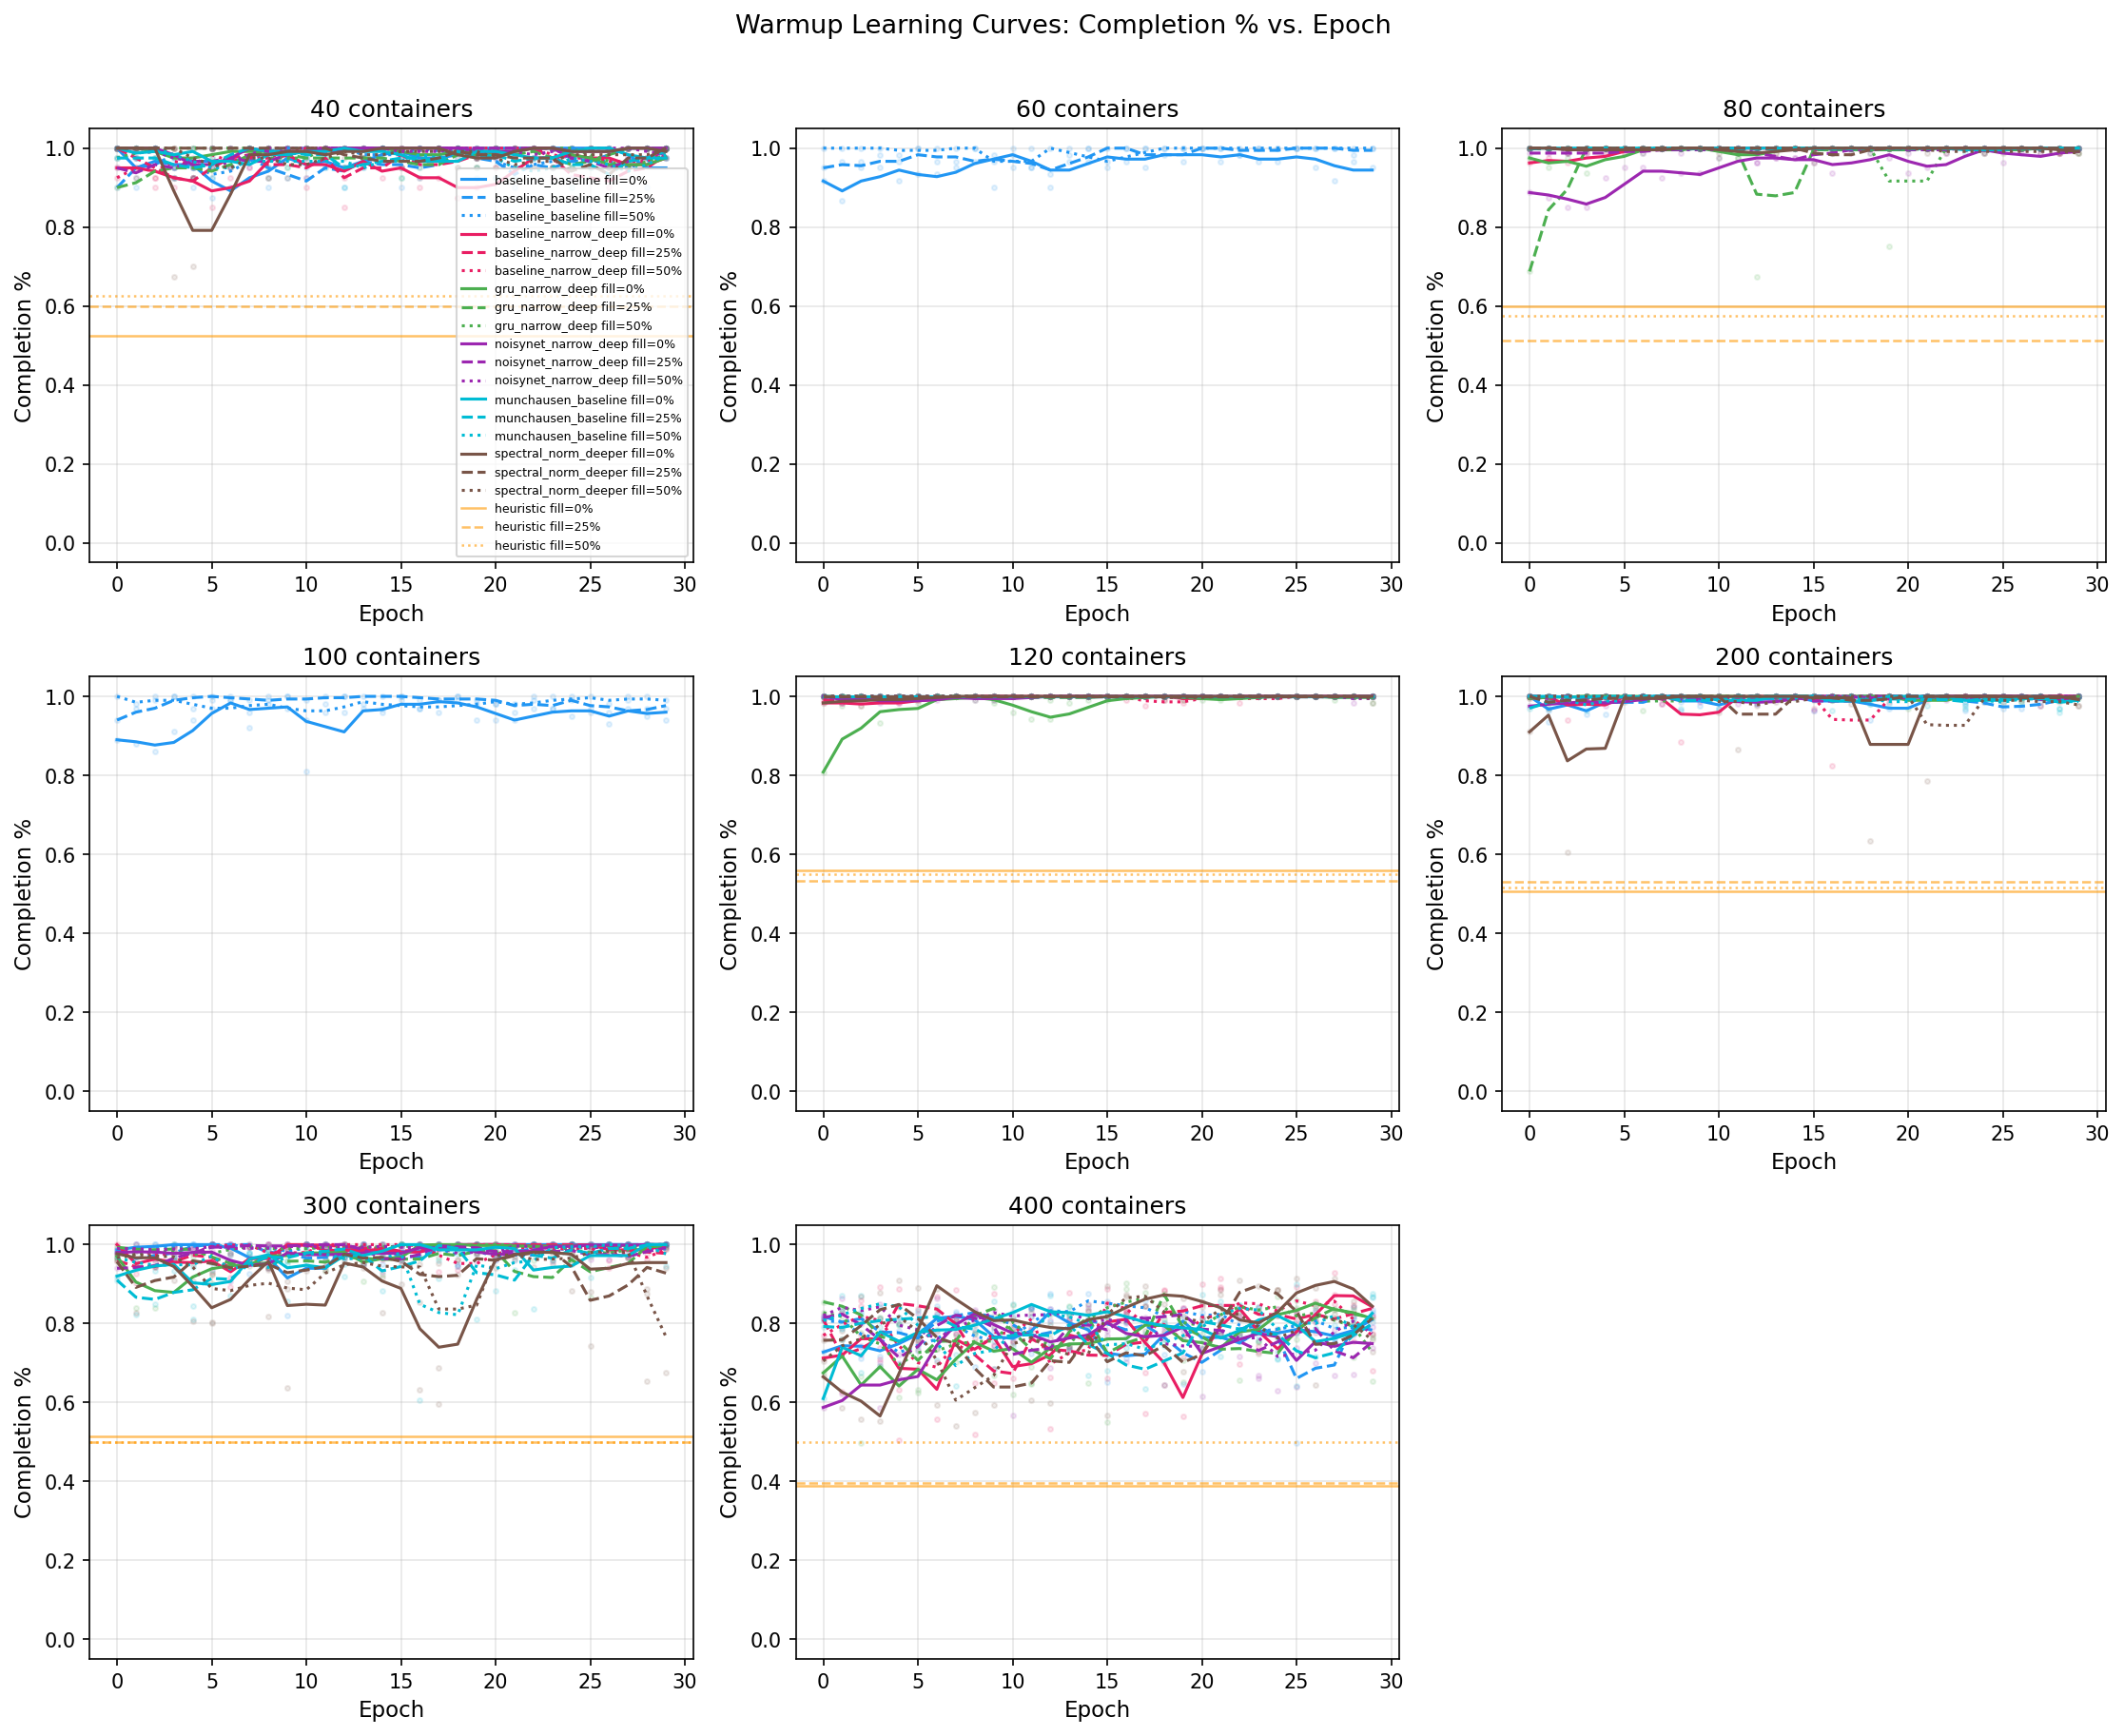

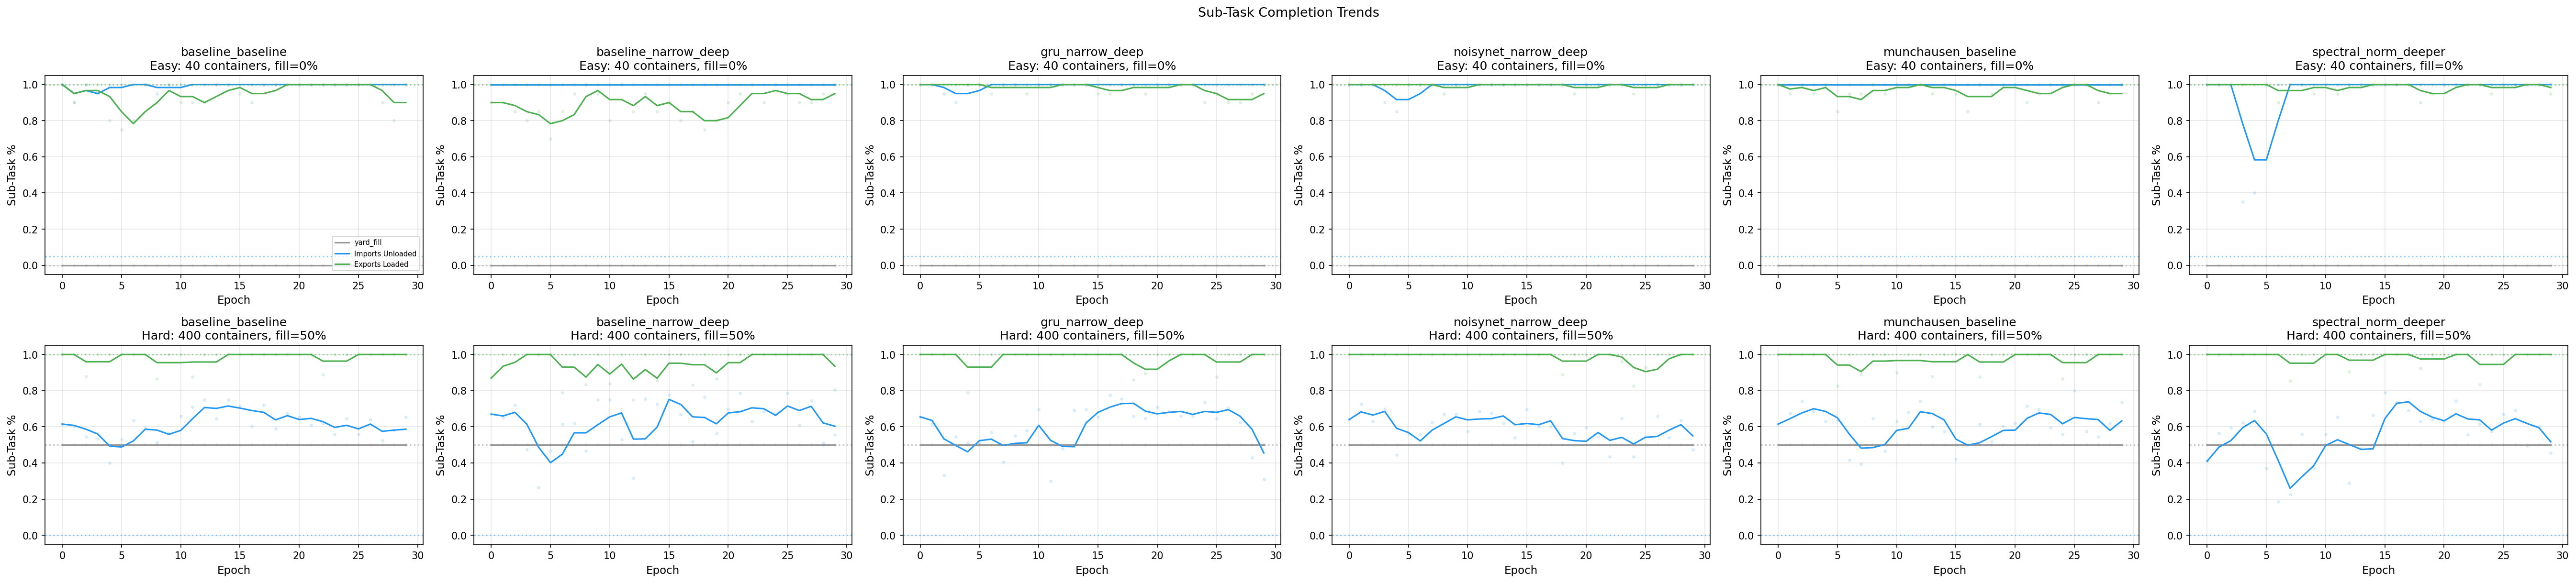

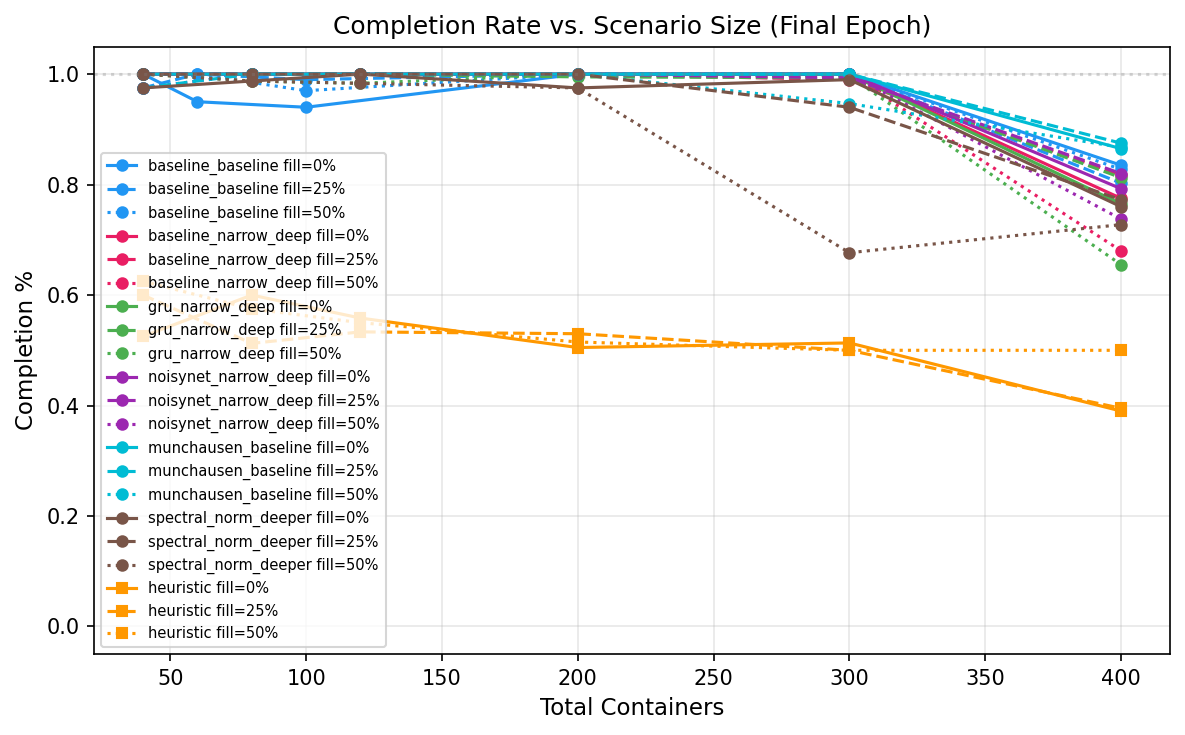

/tmp/ipykernel_220294/606917553.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


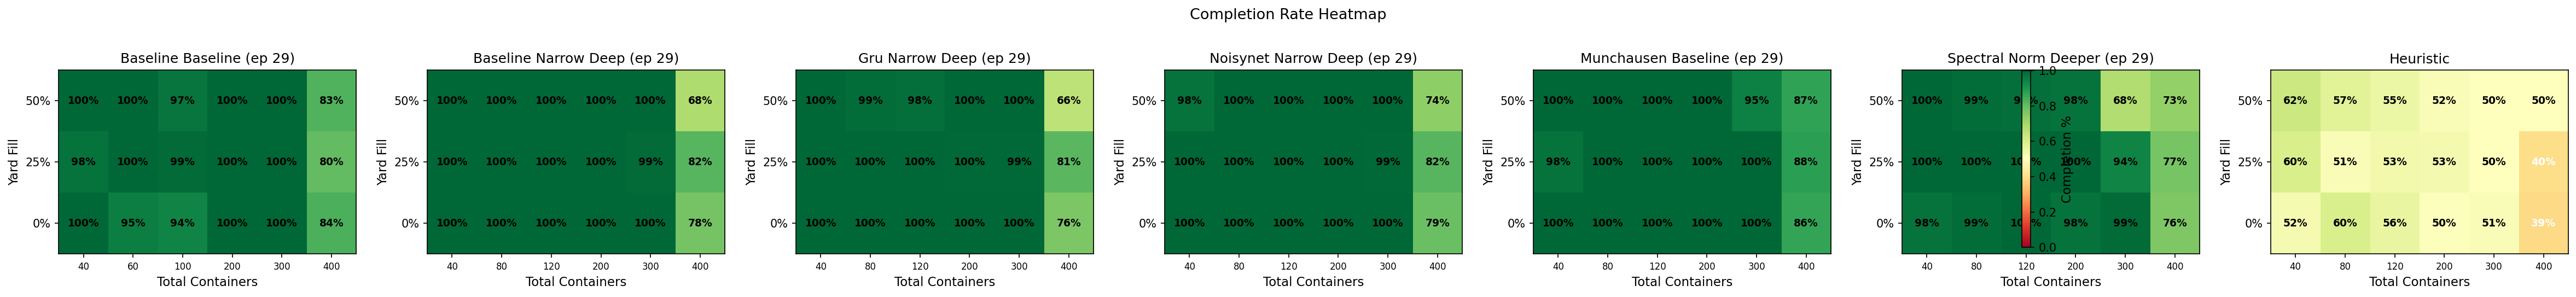

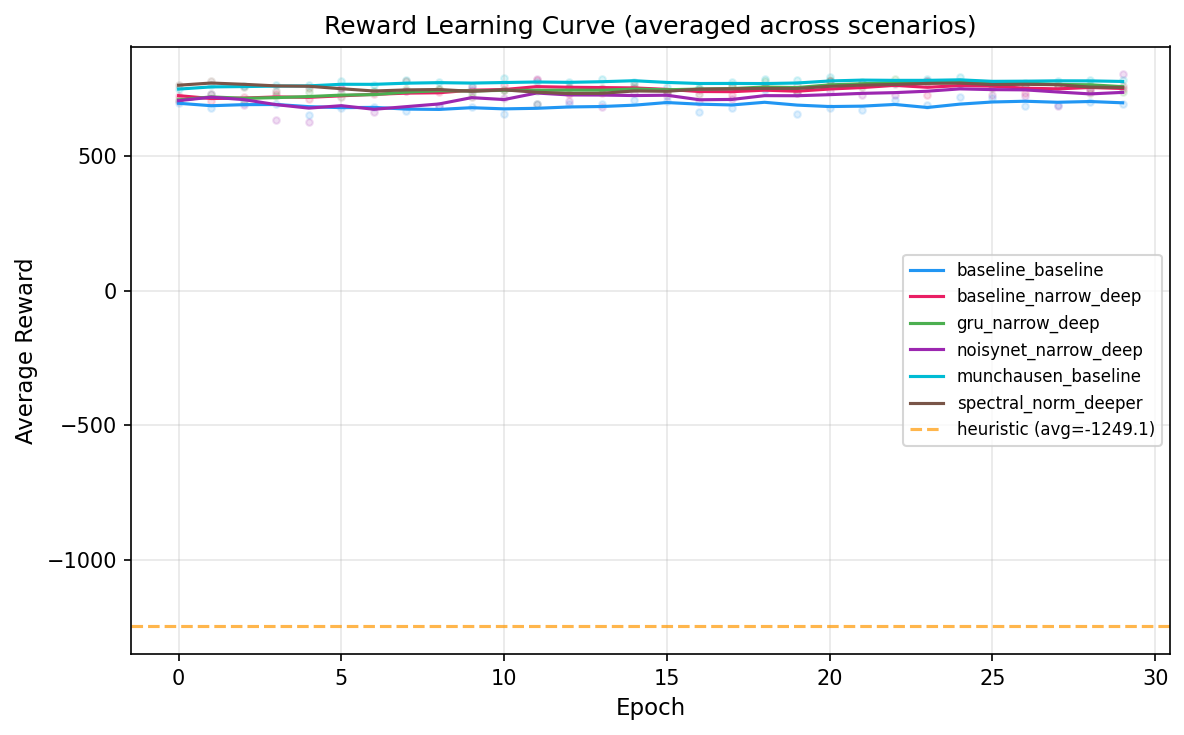

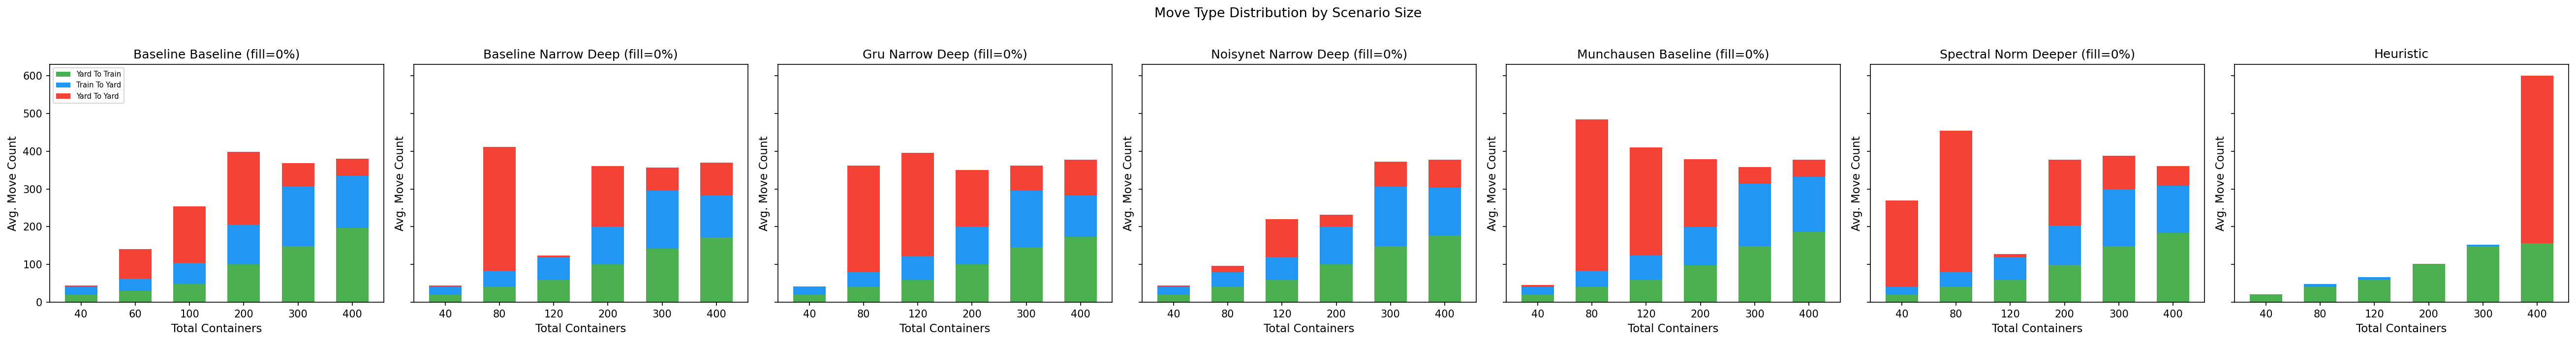

In [8]:
# ================================================================
# Cell 8: Thesis Figures
# ================================================================

# ── Colour & styling ──────────────────────────────────────────
_COLOR_CYCLE = ['#2196F3', '#E91E63', '#4CAF50', '#9C27B0', '#00BCD4', '#795548']
AGENT_COLORS = {}
for i, (v, b) in enumerate(AGENTS_TO_EVAL):
    AGENT_COLORS[agent_label(v, b)] = _COLOR_CYCLE[i % len(_COLOR_CYCLE)]
AGENT_COLORS['heuristic'] = '#FF9800'

FILL_STYLES = {0.0: '-', 0.25: '--', 0.50: ':'}
FILL_LABELS = {0.0: '0%', 0.25: '25%', 0.50: '50%'}

SUBTASK_COLORS = {
    'imports_unloaded_pct': '#2196F3',
    'exports_loaded_pct': '#4CAF50',
    'deliveries_served_pct': '#FF9800',
    'pickups_served_pct': '#E91E63',
    'train_to_truck_done_pct': '#9C27B0',
    'truck_to_train_done_pct': '#00BCD4',
}
SUBTASK_LABELS = {
    'imports_unloaded_pct': 'Imports Unloaded',
    'exports_loaded_pct': 'Exports Loaded',
    'deliveries_served_pct': 'Deliveries Served',
    'pickups_served_pct': 'Pickups Served',
    'train_to_truck_done_pct': 'Train\u2192Truck',
    'truck_to_train_done_pct': 'Truck\u2192Train',
}

def _color(label):
    return AGENT_COLORS.get(label, '#607D8B')


# ────────────────────────────────────────────────────────────────
# Figure 1: Completion Learning Curves (faceted by load size)
# ────────────────────────────────────────────────────────────────

def plot_learning_curves(all_curves, smooth_window=3):
    """One subplot per load size. Completion % vs. warmup epoch."""
    # Collect all unique load sizes across all agents
    all_loads = set()
    for df in all_curves.values():
        all_loads.update(int(v) for v in df['total_containers'].unique())
    load_sizes = sorted(all_loads)

    n = len(load_sizes)
    n_cols = min(3, n)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                             squeeze=False)

    dqn_labels = [l for l in all_curves if l != 'heuristic']

    for ax_idx, load in enumerate(load_sizes):
        ax = axes[ax_idx // n_cols, ax_idx % n_cols]

        # DQN agent curves
        for label in dqn_labels:
            df = all_curves[label]
            color = _color(label)
            sub = df[df['total_containers'] == load]

            for fill in sorted(sub['yard_fill_pct'].unique()):
                fill_sub = sub[sub['yard_fill_pct'] == fill].sort_values('epoch')
                if len(fill_sub) == 0:
                    continue
                fill_lbl = FILL_LABELS.get(fill, f'{fill:.0%}')
                style = FILL_STYLES.get(fill, '-.')

                y = fill_sub['completion_pct'].values
                x = fill_sub['epoch'].values
                if len(y) >= smooth_window:
                    y_smooth = pd.Series(y).rolling(
                        smooth_window, min_periods=1).mean().values
                else:
                    y_smooth = y

                lbl = f'{label} fill={fill_lbl}' if len(dqn_labels) > 1 else f'fill={fill_lbl}'
                ax.plot(x, y_smooth, linestyle=style, color=color,
                        linewidth=1.5, label=lbl)
                ax.scatter(x, y, color=color, alpha=0.12, s=6, zorder=1)

        # Heuristic horizontal lines
        if 'heuristic' in all_curves:
            h_df = all_curves['heuristic']
            h_sub = h_df[h_df['total_containers'] == load]
            for fill in sorted(h_sub['yard_fill_pct'].unique()):
                h_val = h_sub[h_sub['yard_fill_pct'] == fill]['completion_pct'].mean()
                fill_lbl = FILL_LABELS.get(fill, f'{fill:.0%}')
                style = FILL_STYLES.get(fill, '-.')
                ax.axhline(h_val, color=_color('heuristic'),
                          linestyle=style, alpha=0.6, linewidth=1.2,
                          label=f'heuristic fill={fill_lbl}')

        ax.set_title(f'{load} containers')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Completion %')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        if ax_idx == 0:
            ax.legend(fontsize=6, loc='lower right')

    for idx in range(n, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    fig.suptitle('Warmup Learning Curves: Completion % vs. Epoch',
                 fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'learning_curves.png', bbox_inches='tight')
    plt.show()

plot_learning_curves(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 2: Sub-Task Learning Curves (easy vs hard scenarios)
# ────────────────────────────────────────────────────────────────

def plot_subtask_curves(all_curves, smooth_window=3):
    """Per-sub-task completion over epochs for easy and hard scenarios."""
    sizes = sorted(LOAD_SIZES)
    scenarios = [
        (sizes[0], 0.0, 'Easy'),
        (sizes[-1], 0.50, 'Hard'),
    ]
    dqn_labels = [l for l in all_curves if l != 'heuristic']
    if not dqn_labels:
        return

    ref_df = all_curves[dqn_labels[0]]
    avail_st = [c for c in ref_df.columns
                if c.endswith('_pct') and c != 'completion_pct']

    n_agents = len(dqn_labels)
    n_scenarios = len(scenarios)
    fig, axes = plt.subplots(n_scenarios, max(1, n_agents),
                             figsize=(6 * n_agents, 4 * n_scenarios),
                             squeeze=False)

    for s_idx, (load, fill, tag) in enumerate(scenarios):
        for a_idx, label in enumerate(dqn_labels):
            ax = axes[s_idx, a_idx]
            df = all_curves[label]
            sub = df[(df['total_containers'] == load)
                     & (df['yard_fill_pct'] == fill)].sort_values('epoch')

            if len(sub) == 0:
                ax.set_visible(False)
                continue

            for st_col in avail_st:
                if st_col not in sub.columns:
                    continue
                vals = sub[st_col].dropna()
                if len(vals) == 0:
                    continue

                y = vals.values
                x = sub['epoch'].values[:len(y)]
                if len(y) >= smooth_window:
                    y_smooth = pd.Series(y).rolling(
                        smooth_window, min_periods=1).mean().values
                else:
                    y_smooth = y

                color = SUBTASK_COLORS.get(st_col, '#999')
                st_label = SUBTASK_LABELS.get(st_col, st_col.replace('_pct', ''))
                ax.plot(x, y_smooth, color=color, linewidth=1.5, label=st_label)
                ax.scatter(sub['epoch'].values[:len(y)], y,
                          color=color, alpha=0.12, s=6, zorder=1)

            # Heuristic reference lines per sub-task
            if 'heuristic' in all_curves:
                h_df = all_curves['heuristic']
                h_sub = h_df[(h_df['total_containers'] == load)
                             & (h_df['yard_fill_pct'] == fill)]
                for st_col in avail_st:
                    if st_col in h_sub.columns and len(h_sub[st_col].dropna()) > 0:
                        h_val = h_sub[st_col].mean()
                        color = SUBTASK_COLORS.get(st_col, '#999')
                        ax.axhline(h_val, color=color, linestyle=':', alpha=0.5)

            fill_lbl = FILL_LABELS.get(fill, f'{fill:.0%}')
            title = f'{tag}: {load} containers, fill={fill_lbl}'
            if n_agents > 1:
                title = f'{label}\n{title}'
            ax.set_title(title)
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Sub-Task %')
            ax.set_ylim(-0.05, 1.05)
            ax.grid(True, alpha=0.3)
            if s_idx == 0 and a_idx == 0:
                ax.legend(fontsize=7, loc='lower right')

    fig.suptitle('Sub-Task Completion Trends', fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'subtask_curves.png', bbox_inches='tight')
    plt.show()

plot_subtask_curves(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 3: Scaling Curve (final epoch completion vs scenario size)
# ────────────────────────────────────────────────────────────────

def plot_scaling_curve(all_curves):
    """Final-epoch completion vs. total containers for all agents."""
    fig, ax = plt.subplots(figsize=(8, 5))

    for label, df in all_curves.items():
        color = _color(label)
        is_heuristic = (label == 'heuristic')

        if is_heuristic:
            data = df
        else:
            data = df[df['epoch'] == df['epoch'].max()]

        for fill in sorted(data['yard_fill_pct'].unique()):
            sub = data[data['yard_fill_pct'] == fill]
            grp = sub.groupby('total_containers')['completion_pct'].mean().sort_index()

            fill_lbl = FILL_LABELS.get(fill, f'{fill:.0%}')
            style = FILL_STYLES.get(fill, '-.')
            marker = 's' if is_heuristic else 'o'

            ax.plot(grp.index, grp.values,
                    marker=marker, markersize=5,
                    linestyle=style, color=color, linewidth=1.5,
                    label=f'{label} fill={fill_lbl}')

    ax.set_xlabel('Total Containers')
    ax.set_ylabel('Completion %')
    ax.set_title('Completion Rate vs. Scenario Size (Final Epoch)')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(1.0, color='gray', linestyle=':', alpha=0.3)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'scaling_curve.png', bbox_inches='tight')
    plt.show()

plot_scaling_curve(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 4: Completion Heatmap (final epoch)
# ────────────────────────────────────────────────────────────────

def plot_completion_heatmap(all_curves):
    """Heatmap of completion % by load x fill, one per agent."""
    agent_labels = list(all_curves.keys())
    n_agents = len(agent_labels)

    fig, axes = plt.subplots(1, n_agents, figsize=(4.5 * n_agents, 3.5),
                             squeeze=False)

    for idx, label in enumerate(agent_labels):
        ax = axes[0, idx]
        df = all_curves[label]

        if label == 'heuristic':
            data = df
        else:
            data = df[df['epoch'] == df['epoch'].max()]

        fills = sorted(data['yard_fill_pct'].unique())
        loads = sorted(data['total_containers'].unique())

        matrix = np.full((len(fills), len(loads)), np.nan)
        for i, fill in enumerate(fills):
            for j, load in enumerate(loads):
                sub = data[(data['yard_fill_pct'] == fill)
                           & (data['total_containers'] == load)]
                if len(sub) > 0:
                    matrix[i, j] = sub['completion_pct'].mean()

        im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1,
                       aspect='auto', origin='lower')
        ax.set_xticks(range(len(loads)))
        ax.set_xticklabels([str(int(l)) for l in loads], fontsize=8)
        ax.set_yticks(range(len(fills)))
        ax.set_yticklabels([FILL_LABELS.get(f, f'{f:.0%}') for f in fills])
        ax.set_xlabel('Total Containers')
        ax.set_ylabel('Yard Fill')

        title = label.replace('_', ' ').title()
        if label != 'heuristic':
            title += f' (ep {int(df["epoch"].max())})'
        ax.set_title(title)

        for i in range(len(fills)):
            for j in range(len(loads)):
                val = matrix[i, j]
                if not np.isnan(val):
                    color = 'white' if val < 0.5 else 'black'
                    ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                            fontsize=9, fontweight='bold', color=color)

    fig.colorbar(im, ax=axes.ravel().tolist(), label='Completion %',
                 shrink=0.8, pad=0.02)
    fig.suptitle('Completion Rate Heatmap', fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'completion_heatmap.png', bbox_inches='tight')
    plt.show()

plot_completion_heatmap(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 5: Reward Learning Curves
# ────────────────────────────────────────────────────────────────

def plot_reward_curves(all_curves, smooth_window=5):
    """Average reward across all scenarios vs. epoch."""
    dqn_labels = [l for l in all_curves if l != 'heuristic']
    if not dqn_labels:
        return

    fig, ax = plt.subplots(figsize=(8, 5))

    for label in dqn_labels:
        df = all_curves[label]
        color = _color(label)
        grp = df.groupby('epoch')['total_reward'].mean()
        y = grp.values
        if len(y) >= smooth_window:
            y_smooth = pd.Series(y).rolling(
                smooth_window, min_periods=1).mean().values
        else:
            y_smooth = y
        ax.plot(grp.index, y_smooth, color=color, linewidth=1.5, label=label)
        ax.scatter(grp.index, y, color=color, alpha=0.15, s=10, zorder=1)

    # Heuristic average
    if 'heuristic' in all_curves:
        h_mean = all_curves['heuristic']['total_reward'].mean()
        ax.axhline(h_mean, color=_color('heuristic'), linestyle='--',
                   alpha=0.7, label=f'heuristic (avg={h_mean:+.1f})')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Average Reward')
    ax.set_title('Reward Learning Curve (averaged across scenarios)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'reward_curves.png', bbox_inches='tight')
    plt.show()

plot_reward_curves(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 6: Move Distribution (final epoch)
# ────────────────────────────────────────────────────────────────

def plot_move_distribution(all_curves):
    """Stacked bar chart of move types at fill=0%, final epoch."""
    move_types = [
        'YARD_TO_TRAIN', 'TRAIN_TO_YARD', 'PARK_TRUCK',
        'TRUCK_TO_YARD', 'YARD_TO_TRUCK', 'YARD_TO_YARD',
        'TRAIN_TO_TRUCK', 'TRUCK_TO_TRAIN',
    ]
    move_colors = {
        'YARD_TO_TRAIN': '#4CAF50',
        'TRAIN_TO_YARD': '#2196F3',
        'PARK_TRUCK': '#FF9800',
        'TRUCK_TO_YARD': '#9C27B0',
        'YARD_TO_TRUCK': '#E91E63',
        'YARD_TO_YARD': '#F44336',
        'TRAIN_TO_TRUCK': '#00BCD4',
        'TRUCK_TO_TRAIN': '#795548',
    }

    agent_labels = list(all_curves.keys())
    n_agents = len(agent_labels)
    fig, axes = plt.subplots(1, n_agents, figsize=(5 * n_agents, 4.5),
                             squeeze=False, sharey=True)

    for idx, label in enumerate(agent_labels):
        ax = axes[0, idx]
        df = all_curves[label]

        if label == 'heuristic':
            data = df[df['yard_fill_pct'] == 0.0]
        else:
            max_ep = df['epoch'].max()
            data = df[(df['epoch'] == max_ep) & (df['yard_fill_pct'] == 0.0)]

        if len(data) == 0:
            data = df if label == 'heuristic' else df[df['epoch'] == max_ep]

        loads = sorted(data['total_containers'].unique())
        x = np.arange(len(loads))
        width = 0.6

        bottoms = np.zeros(len(loads))
        for mt in move_types:
            col = f'moves_{mt}'
            if col not in data.columns:
                continue
            means = [data[data['total_containers'] == l][col].mean()
                     for l in loads]
            means = [m if not np.isnan(m) else 0 for m in means]
            ax.bar(x, means, width, bottom=bottoms,
                   label=mt.replace('_', ' ').title(),
                   color=move_colors.get(mt, '#999'))
            bottoms += np.array(means)

        ax.set_xticks(x)
        ax.set_xticklabels([str(int(l)) for l in loads])
        ax.set_xlabel('Total Containers')
        ax.set_ylabel('Avg. Move Count')
        title = label.replace('_', ' ').title()
        if label != 'heuristic':
            title += ' (fill=0%)'
        ax.set_title(title)

    axes[0, 0].legend(fontsize=7, loc='upper left')
    fig.suptitle('Move Type Distribution by Scenario Size', fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'move_distribution.png', bbox_inches='tight')
    plt.show()

plot_move_distribution(all_curves)

In [9]:
# ================================================================
# Cell 9: Export Results
# ================================================================

# Per-agent CSVs are already saved in Cell 6.
# Just verify they exist and build the comparison table.
for label in all_curves:
    path = OUTPUT_DIR / f'warmup_curves_{label}.csv'
    status = '✓' if path.exists() else '✗ MISSING'
    print(f'  {status}  {path}')

# Combined comparison table (final epoch for DQN, single run for heuristic)
comparison_rows = []
for label, df in all_curves.items():
    if label == 'heuristic':
        data = df
    else:
        data = df[df['epoch'] == df['epoch'].max()]

    comparison_rows.append({
        'agent': label,
        'total_runs': len(data),
        'pass_rate': data['passed'].mean(),
        'avg_completion': data['completion_pct'].mean(),
        'avg_moves_per_container': data['moves_per_container'].mean(),
        'avg_reshuffle_ratio': data['reshuffle_ratio'].mean(),
        'avg_reward': data['total_reward'].mean(),
    })

comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(OUTPUT_DIR / 'agent_comparison.csv', index=False)
print(f'\nSaved comparison: {OUTPUT_DIR / "agent_comparison.csv"}')
print('\n--- Agent Comparison (Final Epoch vs. Heuristic) ---')
print(comparison.to_string(index=False, float_format='%.3f'))

print(f'\nAll figures saved to: {FIG_DIR}')
print('Done!')

  ✓  /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_baseline_baseline.csv
  ✓  /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_baseline_narrow_deep.csv
  ✓  /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_gru_narrow_deep.csv
  ✓  /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_noisynet_narrow_deep.csv
  ✓  /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_munchausen_baseline.csv
  ✓  /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_spectral_norm_deeper.csv
  ✓  /home/franko/CT-DRL-MA/runs/final_eval/warmup_curves_heuristic.csv

Saved comparison: /home/franko/CT-DRL-MA/runs/final_eval/agent_comparison.csv

--- Agent Comparison (Final Epoch vs. Heuristic) ---
               agent  total_runs  pass_rate  avg_completion  avg_moves_per_container  avg_reshuffle_ratio  avg_reward
   baseline_baseline          18      0.556           0.961                    1.639                0.307     696.249
baseline_narrow_deep          18      0.778           0.959           

In [10]:
# ================================================================
# Cell 10: Thesis Figure Styling & Helpers
# ================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# ── LaTeX-compatible styling ──────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.8,
    'lines.markersize': 5,
})

# ── Colorblind-safe palette (Wong 2011) ──────────────────────
AGENT_PALETTE = {
    'baseline_baseline':     '#0072B2',   # Blue
    'baseline_narrow_deep':  '#D55E00',   # Vermillion
    'gru_narrow_deep':       '#009E73',   # Bluish Green
    'noisynet_narrow_deep':  '#CC79A7',   # Reddish Purple
    'munchausen_baseline':          '#E69F00',   # Orange (future)
    'heuristic':             '#888888',   # Grey
    'spectral_norm_deeper':  '#e1c4ff',   # Lillac
}
AGENT_MARKERS = {
    'baseline_baseline':     'o',
    'baseline_narrow_deep':  's',
    'gru_narrow_deep':       'D',
    'noisynet_narrow_deep':  '^',
    'spectral_norm_deeper':  's',
    'munchausen_baseline':   'P',
    'heuristic':             'X',
}
DISPLAY_NAMES = {
    'baseline_baseline':     'DQN Baseline',
    'baseline_narrow_deep':  'DQN Narrow-Deep',
    'gru_narrow_deep':       'GRU-DQN',
    'noisynet_narrow_deep':  'NoisyNet-DQN',
    'munchausen_baseline':   'Munchausen Baseline',
    'spectral_norm_deeper':  'Spectral-Norm Deeper',
    'heuristic':             'Heuristic',
}

def _c(label):  return AGENT_PALETTE.get(label, '#555555')
def _m(label):  return AGENT_MARKERS.get(label, 'o')
def _n(label):  return DISPLAY_NAMES.get(label, label)

def dqn_labels(curves):
    """Return DQN agent labels in consistent order."""
    order = ['baseline_baseline', 'baseline_narrow_deep',
             'gru_narrow_deep', 'noisynet_narrow_deep', 'spectral_norm_deeper', 'munchausen_baseline']
    return [l for l in order if l in curves]

def get_final_epoch(df):
    """Get final-epoch rows for a DQN agent, or all rows for heuristic."""
    return df[df['epoch'] == df['epoch'].max()]

THESIS_FIG_DIR = OUTPUT_DIR / 'thesis_figures'
THESIS_FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Thesis figure directory: {THESIS_FIG_DIR}')
print(f'Agents available: {", ".join(_n(l) for l in all_curves)}')
print(f'Color palette: colorblind-safe (Wong 2011)')

Thesis figure directory: /home/franko/CT-DRL-MA/runs/final_eval/thesis_figures
Agents available: DQN Baseline, DQN Narrow-Deep, GRU-DQN, NoisyNet-DQN, Munchausen Baseline, Spectral-Norm Deeper, Heuristic
Color palette: colorblind-safe (Wong 2011)


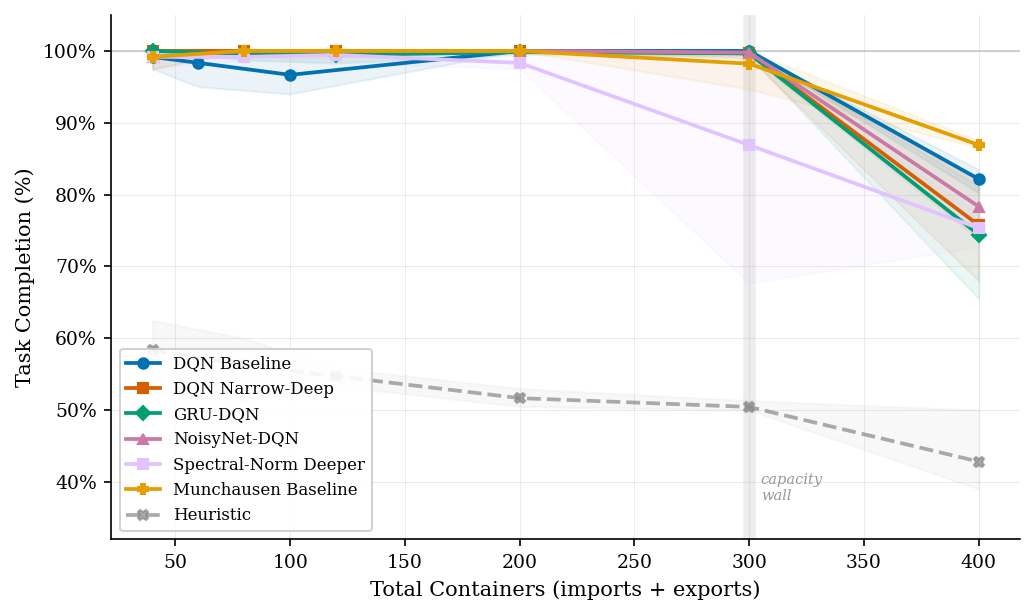

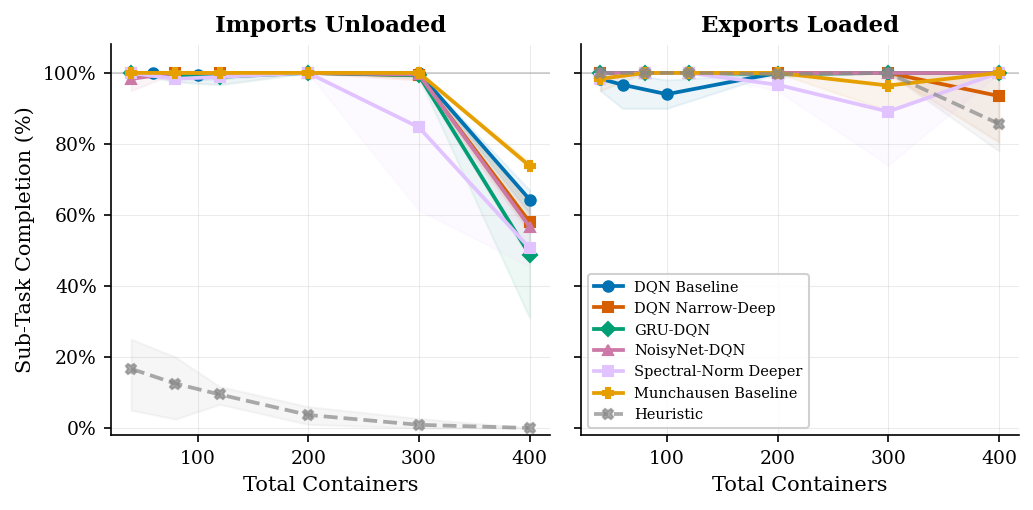

/tmp/ipykernel_220294/2981889844.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.92, 1.0])


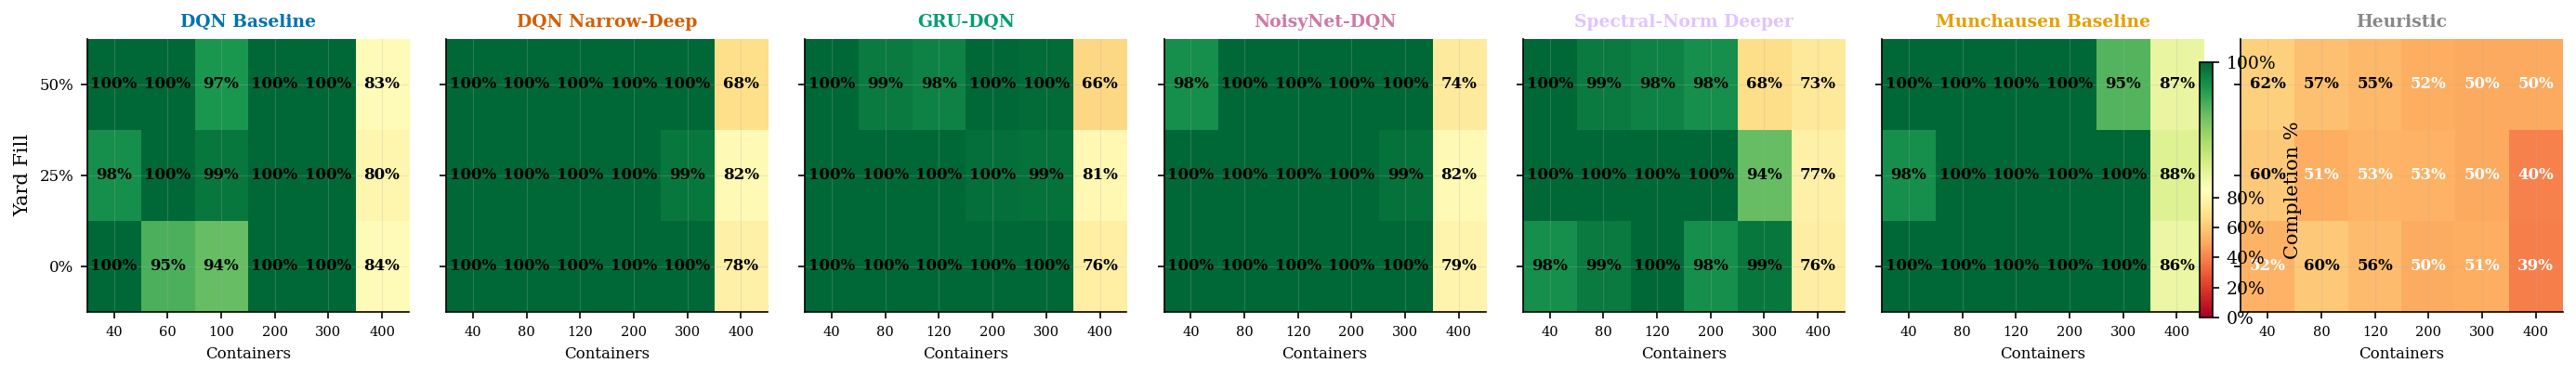

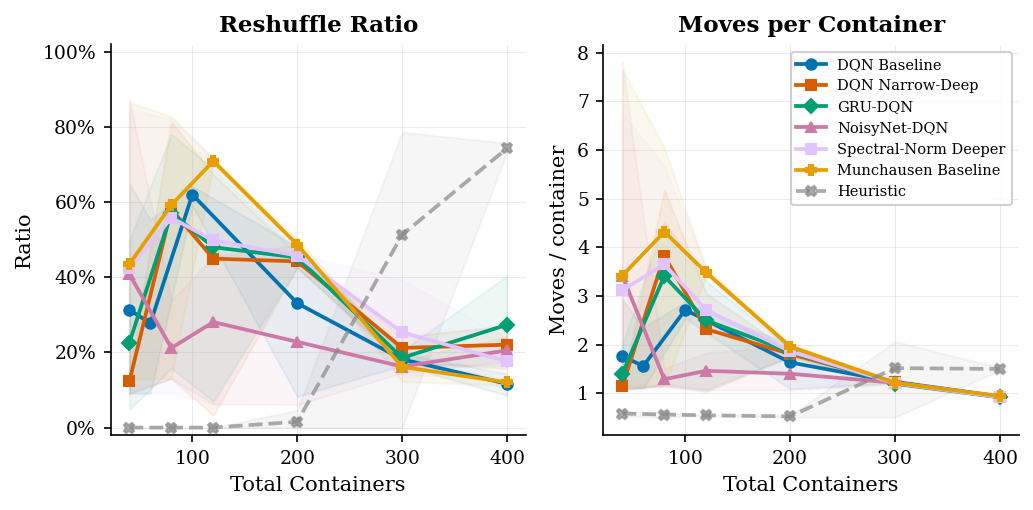

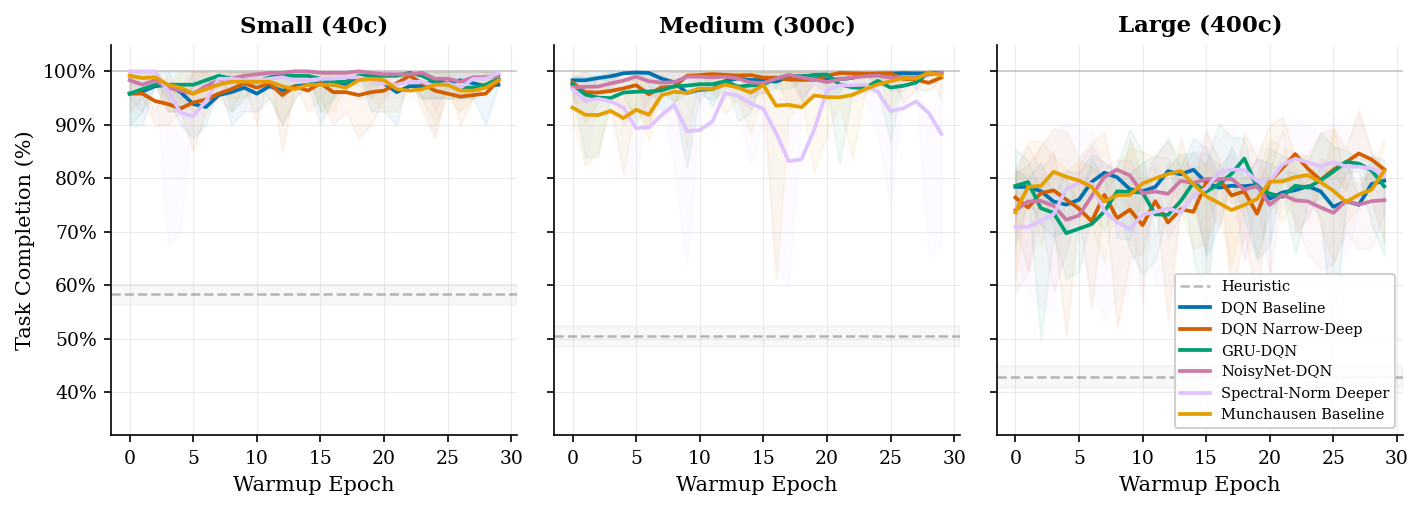

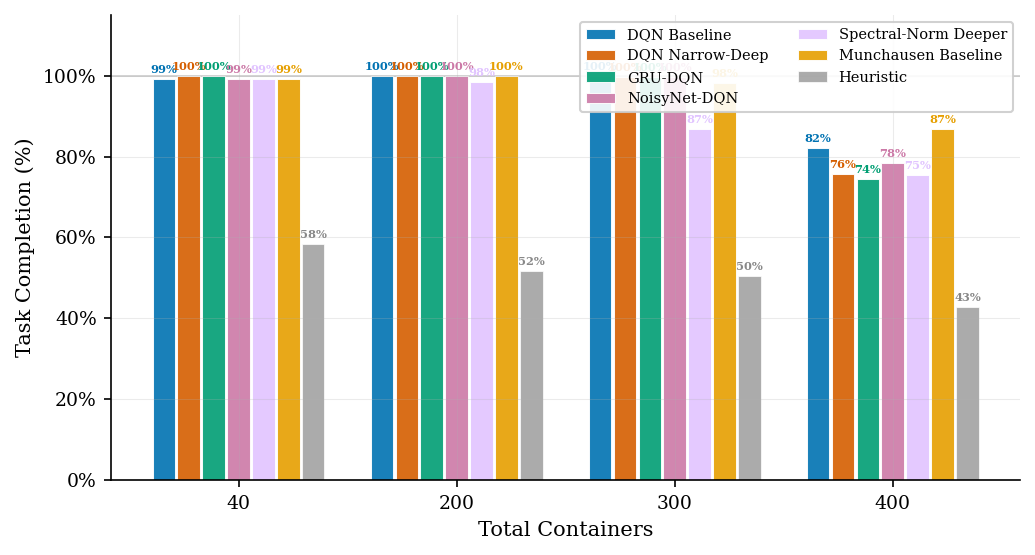

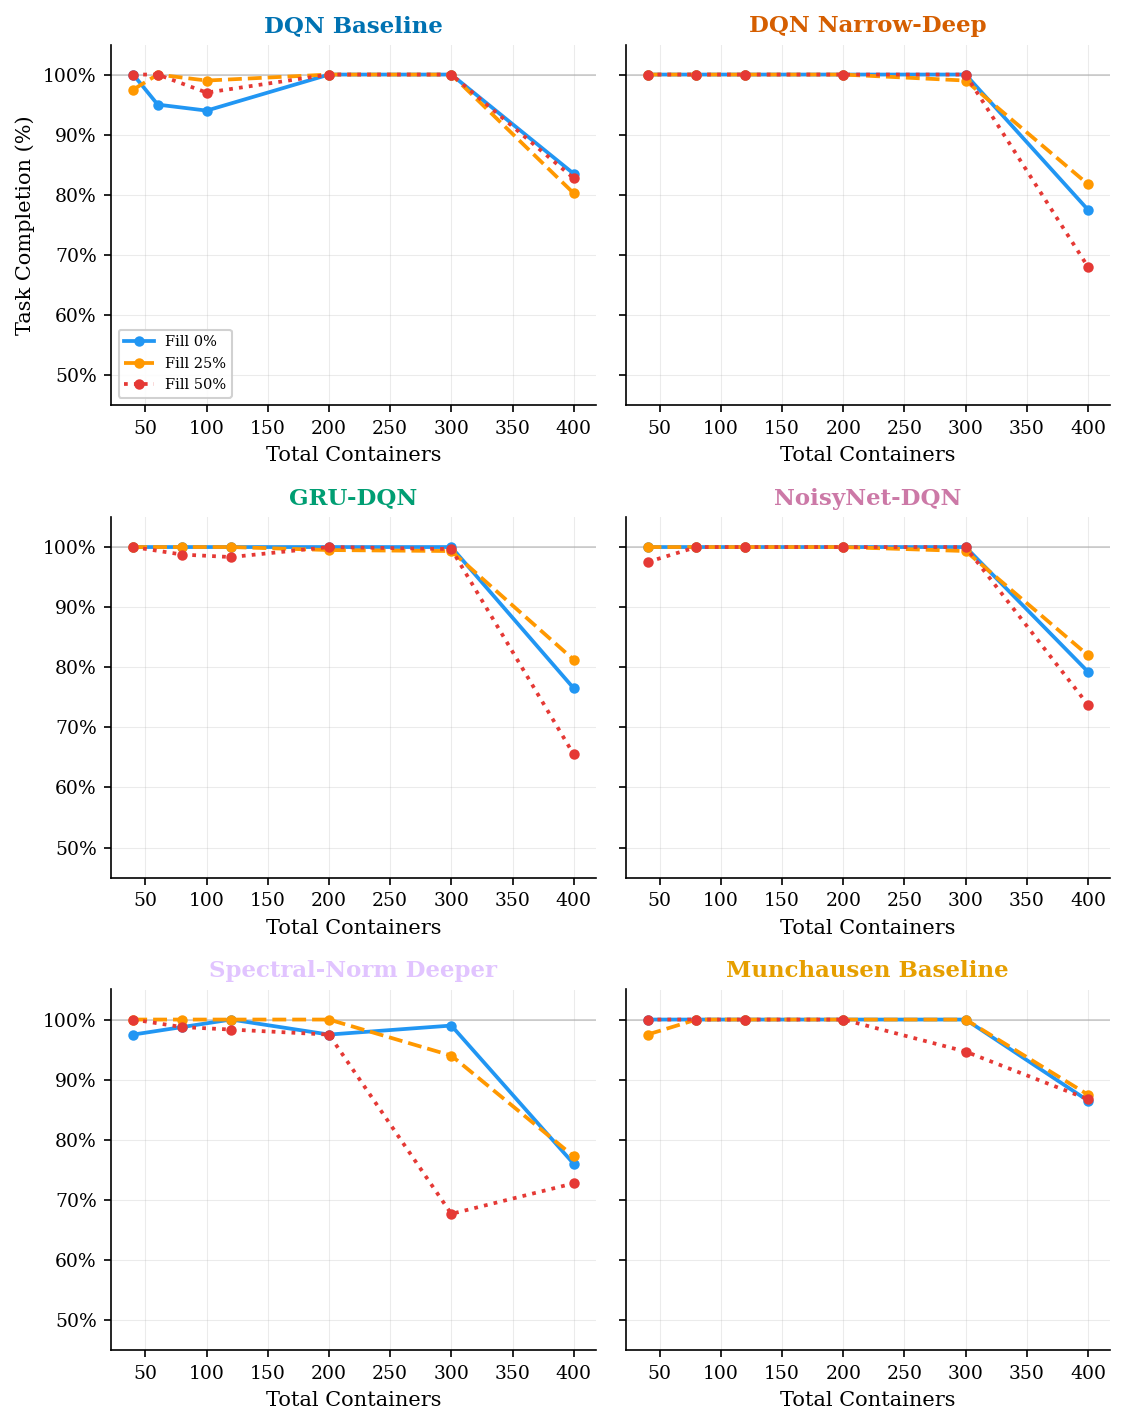


✅ All thesis figures saved to: /home/franko/CT-DRL-MA/runs/final_eval/thesis_figures
   Formats: PNG (for preview) + PDF (for LaTeX \includegraphics)


In [11]:
# ================================================================
# Cell 11: Thesis Figures (publication quality)
# ================================================================

# ────────────────────────────────────────────────────────────────
# Figure 1: SCALING CURVE — Completion vs. Scenario Size
#   Mean across yard fills, with min–max band.
#   Main story: DQN agents maintain ~100% up to 300 containers,
#   graceful degradation at 400. Heuristic flat at ~50%.
# ────────────────────────────────────────────────────────────────
def fig_scaling_curve(curves):
    fig, ax = plt.subplots(figsize=(7, 4.2))

    for label in dqn_labels(curves) + (['heuristic'] if 'heuristic' in curves else []):
        df = curves[label]
        data = get_final_epoch(df)

        grp = data.groupby('total_containers')['completion_pct'].agg(['mean', 'min', 'max'])
        x = grp.index.values
        is_h = (label == 'heuristic')

        ax.plot(x, grp['mean'], marker=_m(label), color=_c(label),
                label=_n(label), zorder=3 if not is_h else 2,
                linestyle='--' if is_h else '-',
                alpha=0.7 if is_h else 1.0)
        ax.fill_between(x, grp['min'], grp['max'],
                        color=_c(label), alpha=0.08 if not is_h else 0.05)

    ax.set_xlabel('Total Containers (imports + exports)')
    ax.set_ylabel('Task Completion (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.set_ylim(0.32, 1.05)
    ax.axhline(1.0, color='#cccccc', linewidth=0.8, zorder=1)

    # Annotate the "capacity wall"
    ax.axvline(300, color='#dddddd', linewidth=6, alpha=0.5, zorder=0)
    ax.text(305, 0.37, 'capacity\nwall', fontsize=7, color='#999999',
            va='bottom', ha='left', style='italic')

    ax.legend(loc='lower left', framealpha=0.9, edgecolor='#cccccc')
    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'scaling_curve.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'scaling_curve.pdf', bbox_inches='tight')
    plt.show()

fig_scaling_curve(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 2: IMPORT / EXPORT ASYMMETRY
#   Side-by-side: Imports Unloaded vs Exports Loaded.
#   Key finding: exports stay at ~100%, imports degrade at scale.
# ────────────────────────────────────────────────────────────────
def fig_import_export_asymmetry(curves):
    fig, (ax_imp, ax_exp) = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True)

    for label in dqn_labels(curves) + (['heuristic'] if 'heuristic' in curves else []):
        df = curves[label]
        data = get_final_epoch(df)
        is_h = (label == 'heuristic')
        ls = '--' if is_h else '-'

        for ax, col, title in [
            (ax_imp, 'imports_unloaded_pct', 'Imports Unloaded'),
            (ax_exp, 'exports_loaded_pct',   'Exports Loaded'),
        ]:
            if col not in data.columns:
                continue
            grp = data.groupby('total_containers')[col].agg(['mean', 'min', 'max'])
            x = grp.index.values
            ax.plot(x, grp['mean'], marker=_m(label), color=_c(label),
                    label=_n(label), linestyle=ls, alpha=0.7 if is_h else 1.0)
            ax.fill_between(x, grp['min'], grp['max'],
                            color=_c(label), alpha=0.07)

    for ax, title in [(ax_imp, 'Imports Unloaded'), (ax_exp, 'Exports Loaded')]:
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Total Containers')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
        ax.set_ylim(-0.02, 1.08)
        ax.axhline(1.0, color='#cccccc', linewidth=0.8, zorder=1)

    ax_imp.set_ylabel('Sub-Task Completion (%)')
    ax_exp.legend(loc='lower left', framealpha=0.9, edgecolor='#cccccc',
                  fontsize=7)

    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'import_export_asymmetry.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'import_export_asymmetry.pdf', bbox_inches='tight')
    plt.show()

fig_import_export_asymmetry(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 3: COMPLETION HEATMAP (improved)
#   One row per agent, cells = load × fill.
#   Diverging colormap centred on 90% to highlight where agents
#   begin to struggle.
# ────────────────────────────────────────────────────────────────
def fig_completion_heatmap(curves):
    agent_order = dqn_labels(curves) + (['heuristic'] if 'heuristic' in curves else [])
    n_agents = len(agent_order)

    # Collect all unique load sizes and fills
    all_loads = sorted(set(
        int(v) for df in curves.values()
        for v in df['total_containers'].unique()
    ))
    all_fills = sorted(set(
        float(v) for df in curves.values()
        for v in df['yard_fill_pct'].unique()
    ))

    fig, axes = plt.subplots(1, n_agents,
                             figsize=(2.8 * n_agents + 0.6, 2.8),
                             squeeze=False)

    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=0.0, vcenter=0.85, vmax=1.0)
    cmap = plt.cm.RdYlGn

    for idx, label in enumerate(agent_order):
        ax = axes[0, idx]
        df = curves[label]
        data = get_final_epoch(df)
        loads = sorted(data['total_containers'].unique())
        fills = sorted(data['yard_fill_pct'].unique())

        matrix = np.full((len(fills), len(loads)), np.nan)
        for i, fill in enumerate(fills):
            for j, load in enumerate(loads):
                sub = data[(data['yard_fill_pct'] == fill)
                           & (data['total_containers'] == load)]
                if len(sub) > 0:
                    matrix[i, j] = sub['completion_pct'].mean()

        im = ax.imshow(matrix, cmap=cmap, norm=norm,
                       aspect='auto', origin='lower')

        ax.set_xticks(range(len(loads)))
        ax.set_xticklabels([str(int(l)) for l in loads], fontsize=7)
        ax.set_yticks(range(len(fills)))
        ax.set_yticklabels([f'{f:.0%}' for f in fills], fontsize=8)

        if idx == 0:
            ax.set_ylabel('Yard Fill')
        else:
            ax.set_yticklabels([])
        ax.set_xlabel('Containers', fontsize=8)
        ax.set_title(_n(label), fontsize=9, fontweight='bold',
                     color=_c(label))

        # Cell text
        for i in range(len(fills)):
            for j in range(len(loads)):
                val = matrix[i, j]
                if not np.isnan(val):
                    txt_color = 'white' if val < 0.55 else 'black'
                    ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                            fontsize=8, fontweight='bold', color=txt_color)

    fig.colorbar(im, ax=axes.ravel().tolist(), label='Completion %',
                 shrink=0.85, pad=0.03, format=mticker.PercentFormatter(1.0, 0))
    fig.tight_layout(rect=[0, 0, 0.92, 1.0])
    fig.savefig(THESIS_FIG_DIR / 'completion_heatmap.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'completion_heatmap.pdf', bbox_inches='tight')
    plt.show()

fig_completion_heatmap(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 4: MOVE EFFICIENCY
#   Left: reshuffle ratio (YARD_TO_YARD / total). Lower = better.
#   Right: moves per container. Lower = more efficient.
# ────────────────────────────────────────────────────────────────
def fig_move_efficiency(curves):
    fig, (ax_r, ax_m) = plt.subplots(1, 2, figsize=(7, 3.5))

    for label in dqn_labels(curves) + (['heuristic'] if 'heuristic' in curves else []):
        df = curves[label]
        data = get_final_epoch(df)
        is_h = (label == 'heuristic')
        ls = '--' if is_h else '-'

        for ax, col, title in [
            (ax_r, 'reshuffle_ratio',       'Reshuffle Ratio (YARD→YARD / total)'),
            (ax_m, 'moves_per_container',   'Moves per Container'),
        ]:
            grp = data.groupby('total_containers')[col].agg(['mean', 'min', 'max'])
            x = grp.index.values
            ax.plot(x, grp['mean'], marker=_m(label), color=_c(label),
                    label=_n(label), linestyle=ls, alpha=0.7 if is_h else 1.0)
            ax.fill_between(x, grp['min'], grp['max'],
                            color=_c(label), alpha=0.07)

    ax_r.set_title('Reshuffle Ratio', fontweight='bold')
    ax_r.set_xlabel('Total Containers')
    ax_r.set_ylabel('Ratio')
    ax_r.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax_r.set_ylim(-0.02, 1.02)

    ax_m.set_title('Moves per Container', fontweight='bold')
    ax_m.set_xlabel('Total Containers')
    ax_m.set_ylabel('Moves / container')
    ax_m.legend(loc='best', framealpha=0.9, edgecolor='#cccccc', fontsize=7)

    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'move_efficiency.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'move_efficiency.pdf', bbox_inches='tight')
    plt.show()

fig_move_efficiency(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 5: LEARNING DYNAMICS (3 representative sizes)
#   Small / Medium / Large — all DQN agents overlaid.
#   Mean across fills. Heuristic as horizontal reference.
# ────────────────────────────────────────────────────────────────
def fig_learning_dynamics(curves, smooth=3):
    # Pick 3 representative sizes from the most common set
    common_sizes = sorted(set.intersection(*(
        set(int(v) for v in df['total_containers'].unique())
        for df in curves.values()
    )))
    if len(common_sizes) >= 3:
        pick = [common_sizes[0], common_sizes[len(common_sizes)//2], common_sizes[-1]]
    else:
        pick = common_sizes
    labels_list = ['Small', 'Medium', 'Large']

    fig, axes = plt.subplots(1, len(pick), figsize=(3.2 * len(pick), 3.5),
                             sharey=True, squeeze=False)

    for p_idx, (load, size_label) in enumerate(zip(pick, labels_list)):
        ax = axes[0, p_idx]

        # Heuristic reference
        if 'heuristic' in curves:
            h_df = curves['heuristic']
            h_sub = h_df[h_df['total_containers'] == load]
            if len(h_sub) > 0:
                h_val = h_sub['completion_pct'].mean()
                ax.axhline(h_val, color=_c('heuristic'), linestyle='--',
                          alpha=0.6, linewidth=1.2, label=_n('heuristic'))
                ax.axhspan(h_val - 0.02, h_val + 0.02,
                          color=_c('heuristic'), alpha=0.06)

        # DQN learning curves
        for label in dqn_labels(curves):
            df = curves[label]
            sub = df[df['total_containers'] == load]
            if len(sub) == 0:
                continue
            grp = sub.groupby('epoch')['completion_pct'].agg(['mean', 'min', 'max'])

            y = grp['mean'].values
            x = grp.index.values
            if len(y) >= smooth:
                y_smooth = pd.Series(y).rolling(smooth, min_periods=1).mean().values
            else:
                y_smooth = y

            ax.plot(x, y_smooth, color=_c(label), label=_n(label))
            ax.fill_between(x, grp['min'], grp['max'],
                           color=_c(label), alpha=0.06)

        ax.set_title(f'{size_label} ({load}c)', fontweight='bold')
        ax.set_xlabel('Warmup Epoch')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
        ax.set_ylim(0.32, 1.05)
        ax.axhline(1.0, color='#cccccc', linewidth=0.8, zorder=1)

    axes[0, 0].set_ylabel('Task Completion (%)')
    axes[0, -1].legend(loc='lower right', framealpha=0.9,
                       edgecolor='#cccccc', fontsize=7)

    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'learning_dynamics.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'learning_dynamics.pdf', bbox_inches='tight')
    plt.show()

fig_learning_dynamics(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 6: AGENT COMPARISON BAR CHART
#   Grouped bars: completion % by scenario size (final epoch).
#   Mean across fills. Clear side-by-side comparison.
# ────────────────────────────────────────────────────────────────
def fig_agent_comparison_bars(curves):
    agent_order = dqn_labels(curves) + (['heuristic'] if 'heuristic' in curves else [])

    # Use common sizes for fair comparison
    common_sizes = sorted(set.intersection(*(
        set(int(v) for v in curves[l]['total_containers'].unique())
        for l in agent_order
    )))

    n_sizes = len(common_sizes)
    n_agents = len(agent_order)
    bar_w = 0.8 / n_agents
    x = np.arange(n_sizes)

    fig, ax = plt.subplots(figsize=(7, 3.8))

    for a_idx, label in enumerate(agent_order):
        df = curves[label]
        data = get_final_epoch(df)
        vals = []
        for load in common_sizes:
            sub = data[data['total_containers'] == load]
            vals.append(sub['completion_pct'].mean() if len(sub) > 0 else 0)

        offset = (a_idx - n_agents / 2 + 0.5) * bar_w
        bars = ax.bar(x + offset, vals, bar_w * 0.9,
                      label=_n(label), color=_c(label),
                      edgecolor='white', linewidth=0.5,
                      alpha=0.7 if label == 'heuristic' else 0.9)

        # Value labels on top of bars
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'{val:.0%}', ha='center', va='bottom',
                        fontsize=5.5, color=_c(label), fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}' for s in common_sizes])
    ax.set_xlabel('Total Containers')
    ax.set_ylabel('Task Completion (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.set_ylim(0, 1.15)
    ax.axhline(1.0, color='#cccccc', linewidth=0.8, zorder=0)
    ax.legend(loc='upper right', framealpha=0.9, edgecolor='#cccccc',
              ncol=2, fontsize=7)

    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'agent_comparison.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'agent_comparison.pdf', bbox_inches='tight')
    plt.show()

fig_agent_comparison_bars(all_curves)


# ────────────────────────────────────────────────────────────────
# Figure 7: FILL IMPACT — how yard fill affects each agent
#   Separate lines per fill level, one panel per agent (2×2 grid).
#   Shows whether fill matters more at larger scales.
# ────────────────────────────────────────────────────────────────
def fig_fill_impact(curves):
    agents = dqn_labels(curves)
    n = len(agents)
    n_cols = min(2, n)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.8 * n_cols, 3.2 * n_rows),
                             sharey=True, squeeze=False)

    fill_colors = {0.0: '#2196F3', 0.25: '#FF9800', 0.5: '#E53935'}
    fill_styles = {0.0: '-', 0.25: '--', 0.5: ':'}

    for idx, label in enumerate(agents):
        ax = axes[idx // n_cols, idx % n_cols]
        df = curves[label]
        data = get_final_epoch(df)

        for fill in sorted(data['yard_fill_pct'].unique()):
            sub = data[data['yard_fill_pct'] == fill]
            grp = sub.groupby('total_containers')['completion_pct'].mean().sort_index()
            ax.plot(grp.index, grp.values,
                    marker='o', markersize=4,
                    color=fill_colors.get(fill, '#555'),
                    linestyle=fill_styles.get(fill, '-'),
                    label=f'Fill {fill:.0%}')

        ax.set_title(_n(label), fontweight='bold', color=_c(label))
        ax.set_xlabel('Total Containers')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
        ax.set_ylim(0.45, 1.05)
        ax.axhline(1.0, color='#cccccc', linewidth=0.8, zorder=1)

    axes[0, 0].set_ylabel('Task Completion (%)')
    axes[0, 0].legend(loc='lower left', framealpha=0.9,
                      edgecolor='#cccccc', fontsize=7)

    # Hide unused subplots
    for idx in range(n, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'fill_impact.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'fill_impact.pdf', bbox_inches='tight')
    plt.show()

fig_fill_impact(all_curves)


print(f'\n✅ All thesis figures saved to: {THESIS_FIG_DIR}')
print('   Formats: PNG (for preview) + PDF (for LaTeX \\includegraphics)')

In [12]:
# ================================================================
# Cell 12: Mixed-Operation Stress Test (Train + Truck)
#
# Tests the best agent from Phase 2 on scenarios that include
# truck operations alongside train operations.
# Varies: total containers, train/truck ratio, yard fill.
# ================================================================

# ── Configuration ─────────────────────────────────────────────
# Pick your best agent from the train-only results above.
STRESS_AGENT = ("baseline", "baseline")   # (dqn_variant, cnn_backbone)

STRESS_TOTALS = [100, 200, 300]
STRESS_TRAIN_RATIOS = [0.75, 0.50]       # fraction via train; rest via truck
STRESS_FILLS = [0.0, 0.25, 0.50]
STRESS_DIRECT_PCT = 0.10                  # 10% of total go via direct transfer
STRESS_WARMUP_EPOCHS = 30
STRESS_EPSILON = 0.10
STRESS_GRAD_STEPS = 4
STRESS_BASE_SEED = 9000

def build_mixed_grid():
    """Build eval grid varying train/truck ratio with direct transfers.

    For each (total, train_ratio, fill):
      - 10% of total → direct transfers (split evenly: train→truck, truck→train)
      - Remaining 90% split by train_ratio:
        * train portion → imports + exports (evenly)
        * truck portion → delivery + pickup (evenly)

    train_ratio=0.75 → 75% of the non-direct portion via train
    train_ratio=0.50 → 50% via train, 50% via truck
    """
    grid = []
    for i, total in enumerate(STRESS_TOTALS):
        for j, ratio in enumerate(STRESS_TRAIN_RATIOS):
            for k, fill in enumerate(STRESS_FILLS):
                # Direct transfers: 10% of total, split evenly
                n_direct = max(2, int(total * STRESS_DIRECT_PCT))
                n_t2tk = n_direct // 2          # train → truck
                n_tk2t = n_direct - n_t2tk      # truck → train

                # Remaining containers split by train/truck ratio
                n_remaining = total - n_direct
                n_train = int(n_remaining * ratio)
                n_truck = n_remaining - n_train

                n_imp = n_train // 2
                n_exp = n_train - n_imp
                n_del = n_truck // 2            # delivery trucks (bring containers)
                n_pick = n_truck - n_del        # pickup trucks (take containers)

                grid.append(EvalParams(
                    n_imports=n_imp,
                    n_exports=n_exp,
                    n_delivery_trucks=n_del,
                    n_pickup_trucks=n_pick,
                    n_train_to_truck=n_t2tk,
                    n_truck_to_train=n_tk2t,
                    yard_fill_pct=fill,
                    seed=STRESS_BASE_SEED + i * 1000 + j * 100 + k * 10,
                ))
    return grid

stress_grid = build_mixed_grid()

print(f'Stress test agent: {agent_label(*STRESS_AGENT)}')
print(f'Grid: {len(STRESS_TOTALS)} sizes × {len(STRESS_TRAIN_RATIOS)} ratios '
      f'× {len(STRESS_FILLS)} fills = {len(stress_grid)} combos')
print(f'Direct transfers: {STRESS_DIRECT_PCT:.0%} of total '
      f'(split into train→truck + truck→train)')
print(f'Total episodes: {len(stress_grid)} × {STRESS_WARMUP_EPOCHS} '
      f'= {len(stress_grid) * STRESS_WARMUP_EPOCHS}')
print()
print(f'{"Idx":>4s}  {"Total":>5s}  {"Ratio":>5s}  {"Fill":>4s}  '
      f'{"Imp":>4s}  {"Exp":>4s}  {"Del":>4s}  {"Pick":>4s}  '
      f'{"T→Tk":>4s}  {"Tk→T":>4s}  {"Trains":>6s}  {"MaxSt":>6s}')
print('-' * 90)
for i, p in enumerate(stress_grid):
    total = (p.n_imports + p.n_exports + p.n_delivery_trucks +
             p.n_pickup_trucks + p.n_train_to_truck + p.n_truck_to_train)
    ratio = (p.n_imports + p.n_exports) / max(1, total - p.n_train_to_truck - p.n_truck_to_train)
    sc = ScalableEvalScenario(p)
    print(f'  [{i+1:2d}]  {total:5d}  {ratio:5.0%}  {p.yard_fill_pct:4.0%}  '
          f'{p.n_imports:4d}  {p.n_exports:4d}  '
          f'{p.n_delivery_trucks:4d}  {p.n_pickup_trucks:4d}  '
          f'{p.n_train_to_truck:4d}  {p.n_truck_to_train:4d}  '
          f'{sc._n_trains:6d}  {sc.max_steps:6d}')

Stress test agent: baseline_baseline
Grid: 3 sizes × 2 ratios × 3 fills = 18 combos
Direct transfers: 10% of total (split into train→truck + truck→train)
Total episodes: 18 × 30 = 540

 Idx  Total  Ratio  Fill   Imp   Exp   Del  Pick  T→Tk  Tk→T  Trains   MaxSt
------------------------------------------------------------------------------------------
  [ 1]    100    74%    0%    33    34    11    12     5     5       2     474
  [ 2]    100    74%   25%    33    34    11    12     5     5       2     507
  [ 3]    100    74%   50%    33    34    11    12     5     5       2     513
  [ 4]    100    50%    0%    22    23    22    23     5     5       2     540
  [ 5]    100    50%   25%    22    23    22    23     5     5       2     573
  [ 6]    100    50%   50%    22    23    22    23     5     5       2     579
  [ 7]    200    75%    0%    67    68    22    23    10    10       4     945
  [ 8]    200    75%   25%    67    68    22    23    10    10       4    1011
  [ 9]    200  

In [13]:
# ================================================================
# Cell 13: Run Mixed-Operation Stress Test
# ================================================================

stress_label = agent_label(*STRESS_AGENT)
stress_csv = OUTPUT_DIR / f'stress_test_{stress_label}.csv'

if stress_csv.exists():
    print(f'✓ Found existing results: {stress_csv}')
    stress_df = pd.read_csv(stress_csv)
    print(f'  ({len(stress_df)} rows loaded)')
else:
    print(f'Loading agent: {stress_label}')
    stress_agent = load_or_train_agent(*STRESS_AGENT)

    print(f'\nRunning stress test ({len(stress_grid)} combos × '
          f'{STRESS_WARMUP_EPOCHS} epochs)...')
    t0 = time.time()
    stress_df = run_warmup_curves(
        stress_agent, env_factory, stress_grid,
        warmup_epochs=STRESS_WARMUP_EPOCHS,
        warmup_epsilon=STRESS_EPSILON,
        grad_steps_per_epoch=STRESS_GRAD_STEPS,
        agent_label=stress_label,
        verbose=True,
    )
    elapsed = time.time() - t0
    print(f'\n{len(stress_df)} rows in {elapsed:.1f}s ({elapsed/60:.1f}min)')

    stress_df.to_csv(stress_csv, index=False)
    print(f'💾 Saved: {stress_csv}')

    free_agent(stress_agent)
    del stress_agent

# ── Quick summary ─────────────────────────────────────────────
final = stress_df[stress_df['epoch'] == stress_df['epoch'].max()]
print(f'\nStress test summary (final epoch):')
print(f'  Overall completion: {final["completion_pct"].mean():.1%}')
print(f'  Pass rate:          {final["passed"].mean():.0%}')
print()

# Group by total containers and train ratio
final['train_ratio'] = (
    (final['n_imports'] + final['n_exports']) /
    final['total_containers'].clip(lower=1)
)
for total in sorted(final['total_containers'].unique()):
    sub_t = final[final['total_containers'] == total]
    for ratio in sorted(sub_t['train_ratio'].unique()):
        sub = sub_t[sub_t['train_ratio'] == ratio]
        # Get sub-task columns that exist
        st_parts = []
        for col in ['imports_unloaded_pct', 'exports_loaded_pct',
                     'deliveries_served_pct', 'pickups_served_pct']:
            if col in sub.columns and sub[col].notna().any():
                st_parts.append(f'{col.split("_")[0]}={sub[col].mean():.0%}')
        st_str = '  '.join(st_parts)
        print(f'  {int(total):4d}c ratio={ratio:.0%}: '
              f'compl={sub["completion_pct"].mean():.1%}  '
              f'pass={sub["passed"].mean():.0%}  [{st_str}]')

✓ Found existing results: /home/franko/CT-DRL-MA/runs/final_eval/stress_test_baseline_baseline.csv
  (540 rows loaded)

Stress test summary (final epoch):
  Overall completion: 96.9%
  Pass rate:          33%

   100c ratio=45%: compl=100.0%  pass=100%  [imports=100%  exports=100%  deliveries=100%  pickups=100%]
   100c ratio=67%: compl=99.7%  pass=67%  [imports=100%  exports=100%  deliveries=100%  pickups=97%]
   200c ratio=45%: compl=98.7%  pass=0%  [imports=100%  exports=98%  deliveries=100%  pickups=96%]
   200c ratio=68%: compl=99.5%  pass=33%  [imports=100%  exports=100%  deliveries=100%  pickups=97%]
   300c ratio=45%: compl=92.7%  pass=0%  [imports=100%  exports=100%  deliveries=80%  pickups=91%]
   300c ratio=67%: compl=91.1%  pass=0%  [imports=99%  exports=99%  deliveries=50%  pickups=91%]


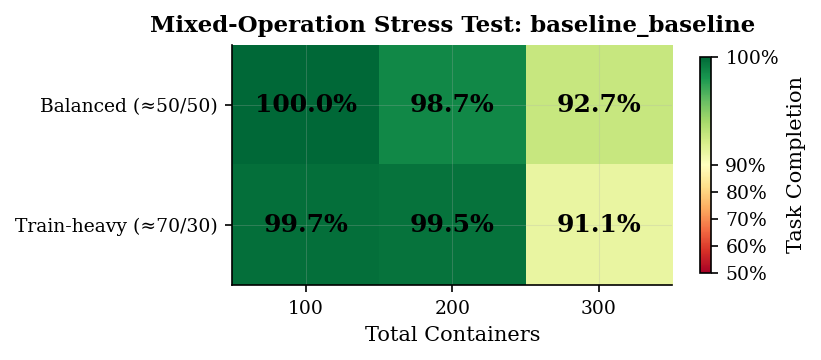

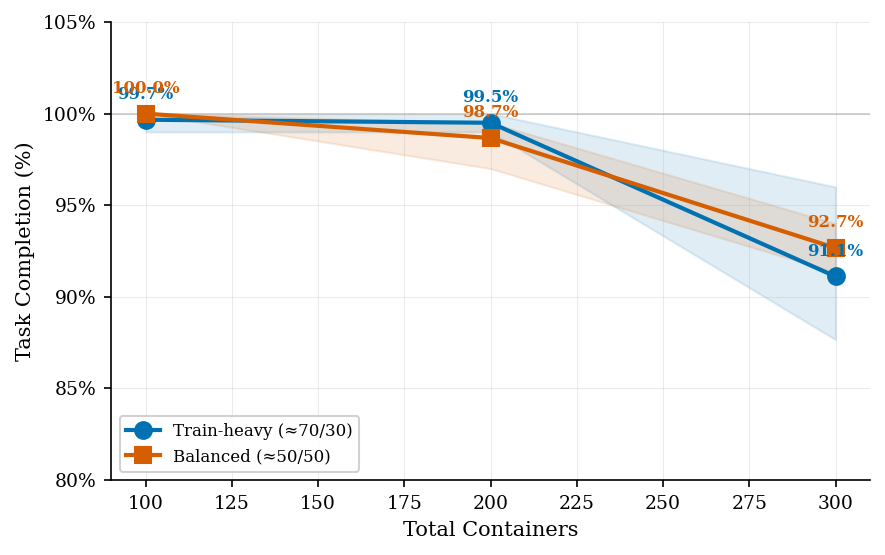

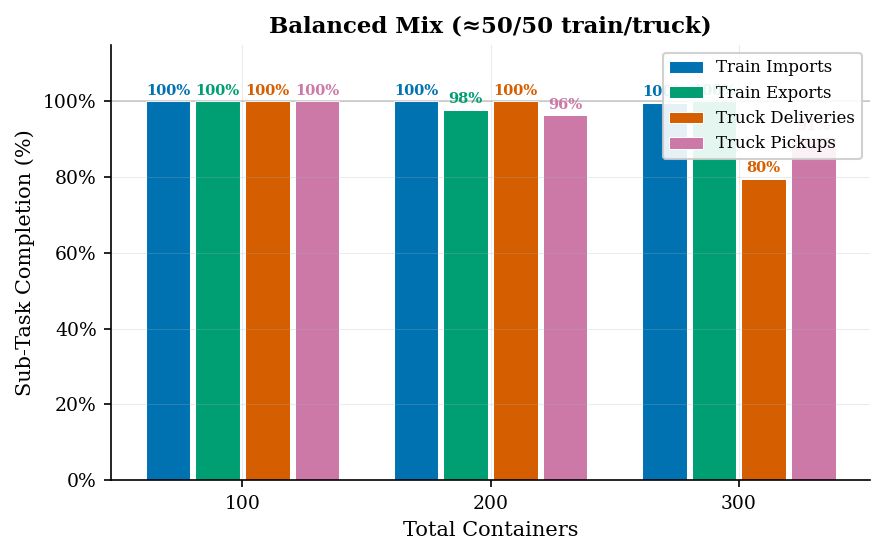

  Copied stress_ratio_impact.png → latex/figures/
  Copied stress_subtask_breakdown.png → latex/figures/
  Copied stress_heatmap.png → latex/figures/

✅ Stress test figures saved to: /home/franko/CT-DRL-MA/runs/final_eval/thesis_figures


In [14]:
# ================================================================
# Cell 14: Stress Test Figures (reworked)
# ================================================================

def _classify_mix(row):
    """Classify each scenario row into a meaningful operation mix label."""
    train = row['n_imports'] + row['n_exports']
    truck = row.get('n_delivery_trucks', 0) + row.get('n_pickup_trucks', 0)
    total = row['total_containers']
    train_frac = train / max(total, 1)
    if train_frac < 0.55:
        return 'Balanced (≈50/50)'
    else:
        return 'Train-heavy (≈70/30)'


def _prepare_stress(stress_df):
    """Add mix label and get final-epoch data."""
    final = stress_df[stress_df['epoch'] == stress_df['epoch'].max()].copy()
    final['mix'] = final.apply(_classify_mix, axis=1)
    return final


# ────────────────────────────────────────────────────────────────
# Figure 1: STRESS HEATMAP — Completion by load × mix
#   Clean 2-row × 3-col heatmap with annotated percentages.
# ────────────────────────────────────────────────────────────────
def fig_stress_heatmap(stress_df):
    final = _prepare_stress(stress_df)

    mixes = ['Balanced (≈50/50)', 'Train-heavy (≈70/30)']
    totals = sorted(final['total_containers'].unique())

    matrix = np.full((len(mixes), len(totals)), np.nan)
    for i, mix in enumerate(mixes):
        for j, total in enumerate(totals):
            sub = final[(final['mix'] == mix) & (final['total_containers'] == total)]
            if len(sub) > 0:
                matrix[i, j] = sub['completion_pct'].mean()

    fig, ax = plt.subplots(figsize=(5.5, 2.5))
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=0.5, vcenter=0.90, vmax=1.0)
    im = ax.imshow(matrix, cmap='RdYlGn', norm=norm, aspect='auto')

    ax.set_xticks(range(len(totals)))
    ax.set_xticklabels([str(int(t)) for t in totals])
    ax.set_yticks(range(len(mixes)))
    ax.set_yticklabels(mixes)
    ax.set_xlabel('Total Containers')

    for i in range(len(mixes)):
        for j in range(len(totals)):
            val = matrix[i, j]
            if not np.isnan(val):
                clr = 'white' if val < 0.6 else 'black'
                ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                        fontsize=12, fontweight='bold', color=clr)

    cbar = fig.colorbar(im, label='Task Completion',
                        format=mticker.PercentFormatter(1.0, 0), shrink=0.9)
    ax.set_title(f'Mixed-Operation Stress Test: {stress_label}', fontweight='bold')
    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'stress_heatmap.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'stress_heatmap.pdf', bbox_inches='tight')
    plt.show()


# ────────────────────────────────────────────────────────────────
# Figure 2: STRESS SCALING — Completion vs load, by mix
#   Two clearly coloured lines showing degradation pattern.
# ────────────────────────────────────────────────────────────────
def fig_stress_ratio_impact(stress_df):
    final = _prepare_stress(stress_df)

    mix_colors = {
        'Balanced (≈50/50)':    '#D55E00',
        'Train-heavy (≈70/30)': '#0072B2',
    }
    mix_markers = {
        'Balanced (≈50/50)':    's',
        'Train-heavy (≈70/30)': 'o',
    }

    fig, ax = plt.subplots(figsize=(6, 3.8))

    for mix in ['Train-heavy (≈70/30)', 'Balanced (≈50/50)']:
        sub = final[final['mix'] == mix]
        grp = sub.groupby('total_containers')['completion_pct'].agg(['mean', 'min', 'max'])
        x = grp.index.values
        color = mix_colors[mix]
        ax.plot(x, grp['mean'], marker=mix_markers[mix], color=color,
                linewidth=2.0, label=mix, markersize=8)
        ax.fill_between(x, grp['min'], grp['max'], color=color, alpha=0.12)

        # Annotate values
        for xi, yi in zip(x, grp['mean']):
            ax.annotate(f'{yi:.1%}', (xi, yi), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=8,
                        fontweight='bold', color=color)

    ax.set_xlabel('Total Containers')
    ax.set_ylabel('Task Completion (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.set_ylim(0.80, 1.05)
    ax.axhline(1.0, color='#cccccc', linewidth=0.8, zorder=1)
    ax.legend(loc='lower left', framealpha=0.9, edgecolor='#cccccc')
    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'stress_ratio_impact.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'stress_ratio_impact.pdf', bbox_inches='tight')
    plt.show()


# ────────────────────────────────────────────────────────────────
# Figure 3: SUBTASK BREAKDOWN — Where does degradation happen?
#   Grouped bar chart: for each load level, show import/export/
#   delivery/pickup completion side by side.
# ────────────────────────────────────────────────────────────────
def fig_stress_subtask_breakdown(stress_df):
    final = _prepare_stress(stress_df)

    subtasks = [
        ('imports_unloaded_pct',   'Train Imports',   '#0072B2'),
        ('exports_loaded_pct',     'Train Exports',   '#009E73'),
        ('deliveries_served_pct',  'Truck Deliveries', '#D55E00'),
        ('pickups_served_pct',     'Truck Pickups',    '#CC79A7'),
    ]
    # Filter to subtasks that exist in the data
    subtasks = [(col, lbl, clr) for col, lbl, clr in subtasks
                if col in final.columns and not final[col].isna().all()]

    # Only show balanced mix (where trucks are actually significant)
    balanced = final[final['mix'] == 'Balanced (≈50/50)']
    totals = sorted(balanced['total_containers'].unique())

    if len(totals) == 0 or len(subtasks) == 0:
        print('No balanced-mix data or subtask columns — skipping.')
        return

    n_sub = len(subtasks)
    bar_w = 0.8 / n_sub
    x = np.arange(len(totals))

    fig, ax = plt.subplots(figsize=(6, 3.8))

    for s_idx, (col, lbl, clr) in enumerate(subtasks):
        vals = []
        for total in totals:
            sub = balanced[balanced['total_containers'] == total]
            vals.append(sub[col].mean() if len(sub) > 0 else 0)

        offset = (s_idx - n_sub / 2 + 0.5) * bar_w
        bars = ax.bar(x + offset, vals, bar_w * 0.9,
                      label=lbl, color=clr, edgecolor='white', linewidth=0.5)

        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{val:.0%}', ha='center', va='bottom',
                        fontsize=7, fontweight='bold', color=clr)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(t)}' for t in totals])
    ax.set_xlabel('Total Containers')
    ax.set_ylabel('Sub-Task Completion (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
    ax.set_ylim(0, 1.15)
    ax.axhline(1.0, color='#cccccc', linewidth=0.8, zorder=0)
    ax.legend(loc='upper right', framealpha=0.9, edgecolor='#cccccc', fontsize=8)
    ax.set_title('Balanced Mix (≈50/50 train/truck)', fontweight='bold')
    fig.tight_layout()
    fig.savefig(THESIS_FIG_DIR / 'stress_subtask_breakdown.png', bbox_inches='tight')
    fig.savefig(THESIS_FIG_DIR / 'stress_subtask_breakdown.pdf', bbox_inches='tight')
    plt.show()


# ── Generate figures ──────────────────────────────────────────
fig_stress_heatmap(stress_df)
fig_stress_ratio_impact(stress_df)
fig_stress_subtask_breakdown(stress_df)

# Copy to latex figures
import shutil
for name in ['stress_ratio_impact', 'stress_subtask_breakdown', 'stress_heatmap']:
    src = THESIS_FIG_DIR / f'{name}.png'
    dst = PROJECT_ROOT / 'latex' / 'figures' / f'{name}.png'
    if src.exists():
        shutil.copy2(src, dst)
        print(f'  Copied {name}.png → latex/figures/')

print(f'\n✅ Stress test figures saved to: {THESIS_FIG_DIR}')
